# Experiment A — Combined MPJPE and PCK Analysis

This notebook evaluates Experiment A predictions by computing both **MPJPE** and **PCK** from the same prediction files.

The current version is flow-period aware:

1. prediction CSV files are discovered under `fp_*/np_*/*.csv`
2. filename metadata is checked against the enclosing `fp_*` and `np_*` folders
3. `flow_period_s` and `network_period_s` are both kept in every table
4. dataset-level MPJPE and PCK are aggregated with point/sample weighting, so different flow periods and network periods are not mixed

The notebook supports both datasets:

- `dhp19`
- `eh36m`

In [116]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional
from pathlib import Path

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)

# Directory Configuration and Constants definitions

In [117]:
# -----------------------------------------------------------------------------
# RESULTS DIRECTORY
# -----------------------------------------------------------------------------
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
RESULTS_ROOT = DATA_DIR / 'MoveEnet_OFK_results'

# -----------------------------------------------------------------------------
# DATASET
# -----------------------------------------------------------------------------
# allowed: 'eh36m', 'dhp19'
DATASET = 'dhp19'

if DATASET == 'dhp19':
    EXP_DATASET_DIR = RESULTS_ROOT / 'MOFK_dhp19_full_test'
    DATA_ROOT = DATA_DIR / 'dhp19_testing_set_S13toS17'
elif DATASET == 'eh36m':
    EXP_DATASET_DIR = RESULTS_ROOT / 'MOFK_eh36m_full_test'
    DATA_ROOT = DATA_DIR / 'eh36m_testing_set_S9S11/events'
else:
    raise ValueError(
        f"Unknown dataset: {DATASET}. Expected 'dhp19' or 'eh36m'."
    )

# -----------------------------------------------------------------------------
# INPUT OPTIONS
# -----------------------------------------------------------------------------
RAW_DIR = EXP_DATASET_DIR / 'results' / 'raw'

MPJPE_EXP_DIR = EXP_DATASET_DIR
PCK_EXP_DIR = EXP_DATASET_DIR

AUTO_FALLBACK_RAW_DIRS = [
    MPJPE_EXP_DIR / 'results' / 'raw',
    PCK_EXP_DIR / 'results' / 'raw',
]

# -----------------------------------------------------------------------------
# OUTPUT FOLDERS
# -----------------------------------------------------------------------------
SUMMARY_DIR = EXP_DATASET_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DATASET_DIR / 'plots'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# EVALUATION SETTINGS
# -----------------------------------------------------------------------------
period_tokens = ['0.02', '0.05', '0.1', '0.2', '0.5']
period_values = [float(x) for x in period_tokens]

# Optical flow periods in seconds (must be a subset of network periods)
of_periods = [0.005, 0.01, 0.02]

# MoveEnet-only does not use optical flow.
# Keep only one copy of its results to avoid duplicated experiments.
MOVENET_ONLY_FLOW_PERIOD = 0.005

# PCK thresholds are normalized by the reference-joint distance.
pck_thresholds = [0.1, 0.2, 0.4, 0.6]

# Reference joints for PCK normalization
# REF_JOINT_1 = 1
# REF_JOINT_2 = 5

REF_JOINT_1 = 2
REF_JOINT_2 = 6


print('DATASET:', DATASET)
print('RAW_DIR:', RAW_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('Network periods:', period_values)
print('Optical flow periods:', of_periods)
print('PCK thresholds:', pck_thresholds)

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'
print(
    f'PCK reference joints: {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) '
    f'and {REF_JOINT_2} ({joint_names[REF_JOINT_2]})'
)

DATASET: dhp19
RAW_DIR: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw
DATA_ROOT: /data/dhp19_testing_set_S13toS17
Network periods: [0.02, 0.05, 0.1, 0.2, 0.5]
Optical flow periods: [0.005, 0.01, 0.02]
PCK thresholds: [0.1, 0.2, 0.4, 0.6]
PCK reference joints: 2 (shoulder_left) and 6 (hip_right)


# Utility functions

In [118]:
def resolve_raw_dir(raw_dir: Path, fallback_dirs):
    if raw_dir.exists():
        return raw_dir
    for d in fallback_dirs:
        if d.exists():
            print(f'RAW_DIR not found, falling back to: {d}')
            return d
    raise FileNotFoundError(
        f'Could not find RAW_DIR={raw_dir} and no fallback raw directory exists.'
    )


def period_to_tag(period_token: str) -> str:
    return str(period_token).replace('.', 'p')


def tag_to_period(tag: str) -> float:
    return float(str(tag).replace('p', '.'))

def period_tag_from_folder(csv_path: Path):
    """
    Extract fp and np tags from folder structure:

        RAW_DIR/fp_0p01/np_0p1/file.csv

    Returns:
        np_tag, fp_tag
    """
    np_folder = csv_path.parent.name          # e.g. np_0p1
    fp_folder = csv_path.parent.parent.name   # e.g. fp_0p01

    if not np_folder.startswith("np_"):
        raise ValueError(f"Unexpected network-period folder: {np_folder}")

    if not fp_folder.startswith("fp_"):
        raise ValueError(f"Unexpected flow-period folder: {fp_folder}")

    np_tag = np_folder.replace("np_", "")
    fp_tag = fp_folder.replace("fp_", "")

    return np_tag, fp_tag


def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV file and extract timestamps + joint coordinates.
    
    CSV format (evaluation format): [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y, velocities_if_requested]
    Returns: (timestamps, joints_array[N_frames, 13_joints, 2_coords])
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')

    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """
    Interpolate GT skeleton coordinates to prediction timestamps.
    """
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)

    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]

        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))

        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt

# Coordinates larger than this are considered corrupted.
# Valid image coordinates should be much smaller than 1,000,000 pixels.
COORD_LIMIT = 1e6


def invalid_joint_points(joints: np.ndarray) -> np.ndarray:
    """
    Return a boolean array of shape [N_frames, 13].

    True means that the corresponding joint contains:
      - NaN
      - infinity
      - an unrealistically large coordinate
    """
    return (
        ~np.isfinite(joints).all(axis=2)
        | (np.abs(joints) > COORD_LIMIT).any(axis=2)
    )


def calculate_pck_binary(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    """
    Returns correctness array of shape [N_frames, 13] for a given normalized PCK threshold.
    """
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)

    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)
    ref_dist = np.maximum(ref_dist, 1e-6)

    return (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)


def extract_metadata_from_name(csv_path: Path, dataset: str = DATASET):
    """
    Parse prediction filename metadata.

    Supported current format:
        <sequence_base>__<channel>_<method>_np_<network_period>_fp_<flow_period>[.csv]

    Examples:
        S13_1_1__ch2dvs_moveenet_ofk_np_0p1_fp_0p01.csv
        S13_1_1__ch2dvs_moveenet_only_np_0p1_fp_0p01.csv
        cam2_S11_Directions__ch0dvs_moveenet_ofk_np_0p01_fp_0p005.csv
        cam2_S11_Directions__ch0dvs_moveenet_only_np_0p01_fp_0p005.csv

    Returns:
        sequence_key, method_name, network_period_s, flow_period_s

    sequence_key includes the channel, for example:
        S13_1_1__ch2dvs
        cam2_S11_Directions__ch0dvs
    """
    if dataset not in {'dhp19', 'eh36m'}:
        raise ValueError(f"Unknown dataset: {dataset}. Expected 'dhp19' or 'eh36m'.")

    name = Path(csv_path).name.strip()
    period_pattern = r'\d+p\d+|\d+'

    pattern = (
        rf'(?P<sequence_base>.+?)__'
        rf'(?P<channel>ch\d+dvs)_'
        rf'(?P<method>moveenet_ofk|moveenet_only|moveenet)_'
        rf'np_(?P<network_period>{period_pattern})_'
        rf'fp_(?P<flow_period>{period_pattern})'
        rf'(?:\.csv)?$'
    )

    m = re.fullmatch(pattern, name)
    if not m:
        raise ValueError(f'Unrecognized filename format for dataset {dataset}: {name}')

    sequence_base = m.group('sequence_base')
    channel = m.group('channel')
    method_key = m.group('method')
    np_tag = m.group('network_period')
    fp_tag = m.group('flow_period')

    sequence_key = f'{sequence_base}__{channel}'

    if method_key == 'moveenet_ofk':
        method = 'MoveEnet + OFK'
    elif method_key in {'moveenet_only', 'moveenet'}:
        method = 'MoveEnet only'
    else:
        raise ValueError(f'Unknown method: {method_key}')

    network_period_s = tag_to_period(np_tag)
    flow_period_s = tag_to_period(fp_tag)

    return sequence_key, method, network_period_s, flow_period_s


def gt_path_from_seq_key(seq_key: str, dataset: str = DATASET) -> Path:
    """
    Construct ground-truth skeleton file path from a sequence key.

    Expected seq_key examples:
        dhp19: S13_1_1__ch2dvs
        dhp19: S13_1_1__ch3dvs
        eh36m: cam2_S11_Directions__ch0dvs

    For dhp19:
        S13_1_1__ch2dvs -> DATA_ROOT / S13_1_1 / ch2GT200Hzskeleton / data.log
        S13_1_1__ch3dvs -> DATA_ROOT / S13_1_1 / ch3GT200Hzskeleton / data.log

    For eh36m:
        cam2_S11_Directions__ch0dvs -> DATA_ROOT / cam2_S11_Directions / ch0GT200Hzskeleton / data.log
    """
    if dataset not in {'dhp19', 'eh36m'}:
        raise ValueError(f"Unknown dataset: {dataset}. Expected 'dhp19' or 'eh36m'.")

    parts = seq_key.split('__')
    channel_dvs = None
    sequence_parts = parts

    if parts and re.fullmatch(r'ch\d+dvs', parts[-1]):
        channel_dvs = parts[-1]
        sequence_parts = parts[:-1]

    rel = Path(*sequence_parts)

    if dataset == 'dhp19':
        if channel_dvs not in {'ch2dvs', 'ch3dvs'}:
            raise ValueError(
                "For dhp19, expected seq_key to end with '__ch2dvs' or '__ch3dvs'. "
                f'Got: {seq_key}'
            )
        gt_folder = channel_dvs.replace('dvs', 'GT200Hzskeleton')

    else:
        gt_folder = 'ch0GT200Hzskeleton'

    return DATA_ROOT / rel / gt_folder / 'data.log'


def set_actual_x_ticks(ax, values):
    """
    Show one x-axis tick for each actual x value.
    Useful when the x-axis is logarithmic and matplotlib would otherwise show only 10, 100, ...
    """
    ticks = sorted(pd.Series(values).dropna().unique())
    if len(ticks) == 0:
        return
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{x:g}' for x in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def plot_metric_by_method_and_flow(
    table: pd.DataFrame,
    x_col: str,
    y_col: str,
    ylabel: str,
    title: str,
    output_path: Path,
    xscale: str = 'log',
    ylim=None,
    yerr_col: Optional[str] = None,
):
    """
    Plot MoveEnet-only once and one MoveEnet + OFK curve
    for each optical-flow period.

    When yerr_col is provided, symmetric error bars are shown.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    def draw_curve(data, label, linestyle):
        if len(data) == 0:
            return

        data = data.sort_values(x_col)

        if yerr_col is not None and yerr_col in data.columns:
            ax.errorbar(
                data[x_col],
                data[y_col],
                yerr=data[yerr_col],
                marker='o',
                linestyle=linestyle,
                linewidth=2,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                data[x_col],
                data[y_col],
                marker='o',
                linestyle=linestyle,
                linewidth=2,
                markersize=6,
                label=label,
            )

    # MoveEnet-only is independent of the flow period.
    moveenet_only = table[
        table['method'] == 'MoveEnet only'
    ]

    draw_curve(
        moveenet_only,
        label='MoveEnet only',
        linestyle='-',
    )

    # MoveEnet + OFK genuinely depends on the flow period.
    ofk_table = table[
        table['method'] == 'MoveEnet + OFK'
    ]

    linestyles = ['--', ':', '-.']

    for index, flow_period_s in enumerate(
        sorted(ofk_table['flow_period_s'].dropna().unique())
    ):
        data = ofk_table[
            np.isclose(
                ofk_table['flow_period_s'],
                flow_period_s,
            )
        ]

        draw_curve(
            data,
            label=f'MoveEnet + OFK, fp={flow_period_s:g} s',
            linestyle=linestyles[index % len(linestyles)],
        )

    if xscale is not None:
        ax.set_xscale(xscale)

    set_actual_x_ticks(ax, table[x_col])

    if x_col == 'detection_rate_hz':
        ax.set_xlabel('Detection rate (Hz)')
    else:
        ax.set_xlabel('Network period (s)')

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)


# Csv file discovery and loading

In [119]:
RAW_DIR = resolve_raw_dir(RAW_DIR, AUTO_FALLBACK_RAW_DIRS)

csv_files = sorted(RAW_DIR.glob('fp_*/np_*/*.csv'))

print('RAW_DIR:', RAW_DIR)
print(f'Found {len(csv_files)} prediction CSV files')

if len(csv_files) == 0:
    raise RuntimeError(
        'No CSV files found in RAW_DIR/fp_*/np_*/*.csv. '
        'Check the experiment output path.'
    )

# csv_files[:10]


RAW_DIR: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw
Found 2400 prediction CSV files


In [120]:
gt_cache = {}
rows = []

print('Processing CSV files and computing per-sequence MPJPE + PCK...')

for idx, csv_path in enumerate(csv_files):
    if idx % 10 == 0:
        print(f'  [{idx}/{len(csv_files)}]')

    seq_key, method, network_period_s, flow_period_s = extract_metadata_from_name(
        csv_path,
        dataset=DATASET
    )

    # Check that the filename metadata agrees with the folder metadata.
    np_folder_tag, fp_folder_tag = period_tag_from_folder(csv_path)
    network_period_from_folder = tag_to_period(np_folder_tag)
    flow_period_from_folder = tag_to_period(fp_folder_tag)

    if not np.isclose(network_period_s, network_period_from_folder):
        raise ValueError(
            'Network period mismatch:\n'
            f'  CSV file: {csv_path.name} -> {network_period_s}\n'
            f'  Folder:   {csv_path.parent.name} -> {network_period_from_folder}\n'
            f'  Full path: {csv_path}'
        )

    if not np.isclose(flow_period_s, flow_period_from_folder):
        raise ValueError(
            'Flow period mismatch:\n'
            f'  CSV file: {csv_path.name} -> {flow_period_s}\n'
            f'  Folder:   {csv_path.parent.parent.name} -> {flow_period_from_folder}\n'
            f'  Full path: {csv_path}'
        )
    
    # MoveEnet-only does not depend on the optical-flow period.
    # Keep only the files from one canonical fp folder.
    if (
        method == 'MoveEnet only'
        and not np.isclose(flow_period_s, MOVENET_ONLY_FLOW_PERIOD)
    ):
        continue

    gt_path = gt_path_from_seq_key(seq_key, dataset=DATASET)

    if not gt_path.exists():
        print(f'Skipping missing GT: {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
            gt_path,
            multi_channel=False
        )

    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    # -------------------------------------------------------------------------
    # Validate prediction and GT coordinates
    # -------------------------------------------------------------------------
    bad_pred = invalid_joint_points(joints_pred)
    bad_gt = invalid_joint_points(joints_gt)

    if bad_pred.any() or bad_gt.any():
        print('\n' + '=' * 80)
        print(f'Invalid coordinates found in sequence: {seq_key}')
        print(f'Method: {method}')
        print(f'Flow period: {flow_period_s}')
        print(f'Network period: {network_period_s}')
        print(f'CSV: {csv_path}')
        print(f'GT:  {gt_path}')

        print(
            f'Invalid prediction joint points: '
            f'{bad_pred.sum()} / {bad_pred.size}'
        )
        print(
            f'Invalid GT joint points: '
            f'{bad_gt.sum()} / {bad_gt.size}'
        )

        if np.isfinite(joints_pred).any():
            print(
                f'Prediction coordinate range: '
                f'{np.nanmin(joints_pred)} -> {np.nanmax(joints_pred)}'
            )

        if np.isfinite(joints_gt).any():
            print(
                f'GT coordinate range: '
                f'{np.nanmin(joints_gt)} -> {np.nanmax(joints_gt)}'
            )

        print('Skipping this CSV.')
        print('=' * 80)

        continue

    # -------------------------------------------------------------------------
    # MPJPE per sequence
    # -------------------------------------------------------------------------
    err = np.linalg.norm(joints_pred - joints_gt, axis=2)   # shape: [N, 13]
    per_joint_err = err.mean(axis=0)                        # shape: [13]
    mpjpe_px = float(err.mean())

    # Population standard deviation over the same errors.
    mpjpe_std_px = float(err.std(ddof=0))

    # Required to calculate the exact dataset-level standard deviation later.
    sum_err_px = float(np.sum(err, dtype=np.float64))
    sum_sq_err_px = float(np.sum(err * err, dtype=np.float64))

    # -------------------------------------------------------------------------
    # PCK per sequence
    # -------------------------------------------------------------------------
    pck_results = {}
    for th in pck_thresholds:
        pck_binary = calculate_pck_binary(joints_pred, joints_gt, th)

        pck_results[f'pck_{th:.1f}'] = float(pck_binary.mean() * 100.0)

        for j, joint in enumerate(joint_names):
            pck_results[f'pck_{th:.1f}_{joint}'] = float(
                pck_binary[:, j].mean() * 100.0
            )

    n_samples = int(err.shape[0])

    row = {
        'csv_path': str(csv_path),
        'sequence': seq_key,
        'method': method,
        'flow_period_s': flow_period_s,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,

        # These make dataset-level weighted aggregation exact.
        'sum_err_px': sum_err_px,
        'sum_sq_err_px': sum_sq_err_px,
        'n_points': int(err.size),

        # Per-sequence MPJPE.
        'mpjpe_px': mpjpe_px,
        'mpjpe_std_px': mpjpe_std_px,
    }

    for i, joint in enumerate(joint_names):
        row[f'mpjpe_{joint}'] = float(per_joint_err[i])
        row[f'sum_err_{joint}'] = float(err[:, i].sum())

    row.update(pck_results)
    rows.append(row)


if len(rows) == 0:
    raise RuntimeError('No valid rows were generated. Check GT paths and CSV files.')


df_seq = (
    pd.DataFrame(rows)
    .sort_values(['flow_period_s', 'network_period_s', 'sequence', 'method'])
    .reset_index(drop=True)
)

print(f'Processed {len(df_seq)} valid sequence/configuration rows')

Processing CSV files and computing per-sequence MPJPE + PCK...
  [0/2400]
  [10/2400]
  [20/2400]
  [30/2400]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [40/2400]
  [50/2400]
  [60/2400]
  [70/2400]
  [80/2400]
  [90/2400]
  [100/2400]
  [110/2400]
  [120/2400]
  [130/2400]
  [140/2400]
  [150/2400]
  [160/2400]
  [170/2400]
  [180/2400]
  [190/2400]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [200/2400]
  [210/2400]
  [220/2400]
  [230/2400]
  [240/2400]
  [250/2400]
  [260/2400]
  [270/2400]
  [280/2400]
  [290/2400]
  [300/2400]
  [310/2400]
  [320/2400]
  [330/2400]
  [340/2400]
  [350/2400]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping missing GT: /data/dhp

In [121]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

pck_cols = [
    f'pck_{th:.1f}'
    for th in pck_thresholds
    if f'pck_{th:.1f}' in df_seq.columns
]

group_cols = [
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
    'method',
]

# -------------------------------------------------------------------------
# Dataset-level weighted aggregation
# -------------------------------------------------------------------------
# MPJPE mean and standard deviation are calculated over all individual
# joint errors from all evaluated frames and sequences.
#
# PCK percentages are converted back to counts before aggregation.
# -------------------------------------------------------------------------

work = df_seq.copy()

for col in pck_cols:
    work[f'{col}_correct_points'] = (
        work[col] / 100.0
    ) * work['n_points']


agg_dict = {
    'sum_err_px': ('sum_err_px', 'sum'),
    'sum_sq_err_px': ('sum_sq_err_px', 'sum'),
    'n_points': ('n_points', 'sum'),
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for col in pck_cols:
    agg_dict[f'{col}_correct_points'] = (
        f'{col}_correct_points',
        'sum',
    )


df_table = (
    work
    .groupby(group_cols, as_index=False)
    .agg(**agg_dict)
)

# Dataset-level MPJPE mean.
df_table['mpjpe_px'] = (
    df_table['sum_err_px'] / df_table['n_points']
)

# Dataset-level population variance:
#
# variance = E[x²] - E[x]²
#
mpjpe_variance = (
    df_table['sum_sq_err_px'] / df_table['n_points']
    - df_table['mpjpe_px'] ** 2
)

# Protect against tiny negative values caused by floating-point rounding.
df_table['mpjpe_std_px'] = np.sqrt(
    np.maximum(mpjpe_variance, 0.0)
)

# Dataset-level PCK.
for col in pck_cols:
    df_table[col] = (
        df_table[f'{col}_correct_points']
        / df_table['n_points']
        * 100.0
    )

df_table = df_table.drop(
    columns=[
        f'{col}_correct_points'
        for col in pck_cols
    ]
)

df_table = (
    df_table
    .sort_values([
        'flow_period_s',
        'network_period_s',
        'method',
    ])
    .reset_index(drop=True)
)

print(f'Created {len(df_table)} dataset-level configurations')

# -----------------------------------------------------------------------------
# MPJPE statistics across sequences
# -----------------------------------------------------------------------------
# Ogni valore utilizzato qui è la MPJPE completa di una sequenza.
# La standard deviation rappresenta quindi la variabilità tra sequenze,
# non la variabilità tra singoli joint e frame.

df_mpjpe_sequence_stats = (
    df_seq
    .groupby(group_cols, as_index=False)
    .agg(
        # Media delle MPJPE delle singole sequenze
        mpjpe_px=('mpjpe_px', 'mean'),

        # Standard deviation tra le MPJPE delle sequenze
        mpjpe_std_px=('mpjpe_px', lambda x: x.std(ddof=1)),

        # Numero di sequenze nel gruppo
        n_sequences=('sequence', 'nunique'),
    )
)

# Standard error della media, disponibile nel caso serva
df_mpjpe_sequence_stats['mpjpe_sem_px'] = (
    df_mpjpe_sequence_stats['mpjpe_std_px']
    / np.sqrt(df_mpjpe_sequence_stats['n_sequences'])
)

df_mpjpe_sequence_stats = (
    df_mpjpe_sequence_stats
    .sort_values([
        'flow_period_s',
        'network_period_s',
        'method',
    ])
    .reset_index(drop=True)
)

display(df_mpjpe_sequence_stats)


Created 20 dataset-level configurations


,flow_period_s,network_period_s,detection_rate_hz,method,mpjpe_px,mpjpe_std_px,n_sequences,mpjpe_sem_px
0,0.005,0.02,50.0,MoveEnet + OFK,6.582725,1.416957,79,0.159420
1,0.005,0.02,50.0,MoveEnet only,6.592754,1.406101,79,0.158199
2,0.005,0.05,20.0,MoveEnet + OFK,6.757507,1.413255,79,0.159004
3,0.005,0.05,20.0,MoveEnet only,6.667718,1.401325,79,0.157661
4,0.005,0.10,10.0,MoveEnet + OFK,7.012050,1.403832,79,0.157943
5,0.005,0.10,10.0,MoveEnet only,6.849102,1.377485,79,0.154979
6,0.005,0.20,5.0,MoveEnet + OFK,7.479718,1.433300,79,0.161259
7,0.005,0.20,5.0,MoveEnet only,7.298885,1.360257,79,0.153041
8,0.005,0.50,2.0,MoveEnet + OFK,8.765007,1.597487,79,0.179731
9,0.005,0.50,2.0,MoveEnet only,8.684989,1.436266,79,0.161593


In [122]:
# -----------------------------------------------------------------------------
# Paired MPJPE comparison:
# MoveEnet + OFK versus MoveEnet only
# -----------------------------------------------------------------------------

# MoveEnet-only baseline.
# Nel notebook MoveEnet-only viene mantenuto soltanto per il flow period
# canonico, ma il controllo viene ripetuto qui per sicurezza.
df_baseline = df_seq[
    (df_seq['method'] == 'MoveEnet only') &
    np.isclose(
        df_seq['flow_period_s'],
        MOVENET_ONLY_FLOW_PERIOD
    )
][
    [
        'sequence',
        'network_period_s',
        'mpjpe_px',
    ]
].copy()

df_baseline = df_baseline.rename(
    columns={
        'mpjpe_px': 'mpjpe_movenet_only_px'
    }
)

# Controlla che esista un solo baseline per ogni sequenza/network period.
duplicate_baseline = df_baseline.duplicated(
    subset=['sequence', 'network_period_s'],
    keep=False
)

if duplicate_baseline.any():
    display(
        df_baseline[duplicate_baseline].sort_values(
            ['sequence', 'network_period_s']
        )
    )

    raise RuntimeError(
        'Multiple MoveEnet-only baselines found for the same '
        'sequence and network period.'
    )


# MoveEnet + OFK results.
df_ofk = df_seq[
    df_seq['method'] == 'MoveEnet + OFK'
][
    [
        'sequence',
        'flow_period_s',
        'network_period_s',
        'detection_rate_hz',
        'mpjpe_px',
    ]
].copy()

df_ofk = df_ofk.rename(
    columns={
        'mpjpe_px': 'mpjpe_ofk_px'
    }
)


# Pair every OFK result with the corresponding MoveEnet-only result.
df_paired = df_ofk.merge(
    df_baseline,
    on=[
        'sequence',
        'network_period_s',
    ],
    how='left',
    validate='many_to_one',
    indicator=True,
)


# Stop if an OFK experiment does not have a matching baseline.
missing_baseline = df_paired['_merge'] != 'both'

if missing_baseline.any():
    display(
        df_paired.loc[
            missing_baseline,
            [
                'sequence',
                'flow_period_s',
                'network_period_s',
                'detection_rate_hz',
            ]
        ]
    )

    raise RuntimeError(
        'Some MoveEnet + OFK rows do not have a matching '
        'MoveEnet-only baseline.'
    )

df_paired = df_paired.drop(columns='_merge')


# Paired difference:
#
# negative value -> OFK is better
# positive value -> OFK is worse
df_paired['delta_mpjpe_px'] = (
    df_paired['mpjpe_ofk_px']
    - df_paired['mpjpe_movenet_only_px']
)

df_paired = (
    df_paired
    .sort_values([
        'flow_period_s',
        'network_period_s',
        'sequence',
    ])
    .reset_index(drop=True)
)

print(f'Created {len(df_paired)} paired comparisons')
display(df_paired.head())

# -----------------------------------------------------------------------------
# Paired bootstrap confidence interval for the mean difference
# -----------------------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 10_000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_SEED = 12345

rng = np.random.default_rng(BOOTSTRAP_SEED)


def bootstrap_mean_ci(
    values,
    rng,
    n_bootstrap=10_000,
    confidence=0.95,
):
    """
    Percentile bootstrap confidence interval for the mean.

    Each value is one paired sequence-level MPJPE difference.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    n = len(values)

    if n == 0:
        return np.nan, np.nan, np.nan

    mean_value = float(values.mean())

    if n == 1:
        return mean_value, np.nan, np.nan

    bootstrap_samples = rng.choice(
        values,
        size=(n_bootstrap, n),
        replace=True,
    )

    bootstrap_means = bootstrap_samples.mean(axis=1)

    alpha = 1.0 - confidence

    ci_low, ci_high = np.quantile(
        bootstrap_means,
        [
            alpha / 2.0,
            1.0 - alpha / 2.0,
        ],
    )

    return (
        mean_value,
        float(ci_low),
        float(ci_high),
    )


summary_rows = []

group_columns = [
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
]

for group_values, group in df_paired.groupby(
    group_columns,
    sort=True,
):
    flow_period_s, network_period_s, detection_rate_hz = group_values

    differences = group['delta_mpjpe_px'].to_numpy()

    mean_delta, ci_low, ci_high = bootstrap_mean_ci(
        differences,
        rng=rng,
        n_bootstrap=BOOTSTRAP_REPETITIONS,
        confidence=BOOTSTRAP_CONFIDENCE,
    )

    summary_rows.append({
        'flow_period_s': flow_period_s,
        'network_period_s': network_period_s,
        'detection_rate_hz': detection_rate_hz,
        'n_sequences': len(differences),

        'mean_delta_mpjpe_px': mean_delta,
        'median_delta_mpjpe_px': float(
            np.median(differences)
        ),

        'ci95_low_px': ci_low,
        'ci95_high_px': ci_high,

        # Percentuale di sequenze nelle quali OFK ha MPJPE inferiore.
        'ofk_better_sequences_percent': float(
            np.mean(differences < 0.0) * 100.0
        ),
    })


df_delta_summary = (
    pd.DataFrame(summary_rows)
    .sort_values([
        'flow_period_s',
        'network_period_s',
    ])
    .reset_index(drop=True)
)


# True quando l'intervallo di confidenza non contiene zero.
df_delta_summary['ci95_excludes_zero'] = (
    (df_delta_summary['ci95_high_px'] < 0.0) |
    (df_delta_summary['ci95_low_px'] > 0.0)
)

display(df_delta_summary)

Created 1185 paired comparisons


,sequence,flow_period_s,network_period_s,detection_rate_hz,mpjpe_ofk_px,mpjpe_movenet_only_px,delta_mpjpe_px
0,S13_1_1__ch2dvs,0.005,0.02,50.0,6.494152,6.344803,0.149350
1,S13_1_1__ch3dvs,0.005,0.02,50.0,5.719454,5.802325,-0.082871
2,S13_1_2__ch2dvs,0.005,0.02,50.0,5.797435,5.787594,0.009840
3,S13_1_2__ch3dvs,0.005,0.02,50.0,5.622438,5.583202,0.039236
4,S13_1_3__ch2dvs,0.005,0.02,50.0,4.418557,4.374629,0.043928


,flow_period_s,network_period_s,detection_rate_hz,n_sequences,mean_delta_mpjpe_px,median_delta_mpjpe_px,ci95_low_px,ci95_high_px,ofk_better_sequences_percent,ci95_excludes_zero
0,0.005,0.02,50.0,79,-0.010029,-0.013890,-0.029179,0.009872,55.696203,False
1,0.005,0.05,20.0,79,0.089789,0.055361,0.048838,0.133574,37.974684,True
2,0.005,0.10,10.0,79,0.162948,0.117707,0.096889,0.240240,36.708861,True
3,0.005,0.20,5.0,79,0.180833,0.140038,0.068776,0.306324,40.506329,True
4,0.005,0.50,2.0,79,0.080018,0.078928,-0.137819,0.315649,45.569620,False
5,0.010,0.02,50.0,79,-0.021713,-0.025442,-0.037559,-0.005605,67.088608,True
6,0.010,0.05,20.0,79,0.061174,0.064363,0.031555,0.092525,39.240506,True
7,0.010,0.10,10.0,79,0.119678,0.085087,0.065705,0.177858,34.177215,True
8,0.010,0.20,5.0,79,0.120379,0.102279,0.024810,0.225507,45.569620,True
9,0.010,0.50,2.0,79,-0.055309,-0.021993,-0.256398,0.153199,51.898734,False


In [123]:
per_seq_path = SUMMARY_DIR / f'{DATASET}_per_sequence_metrics.csv'
dataset_path = SUMMARY_DIR / f'{DATASET}_dataset_metrics.csv'
sequence_stats_path = (
    SUMMARY_DIR / f'{DATASET}_mpjpe_sequence_statistics.csv'
)

paired_path = ( SUMMARY_DIR / f'{DATASET}_mpjpe_paired_differences.csv' )

delta_summary_path = ( SUMMARY_DIR / f'{DATASET}_mpjpe_paired_difference_95ci.csv' )

df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(dataset_path, index=False)
df_mpjpe_sequence_stats.to_csv(sequence_stats_path, index=False)
df_paired.to_csv( paired_path, index=False,)

df_delta_summary.to_csv( delta_summary_path, index=False,)

print('Saved per-sequence metrics:       ', per_seq_path)
print('Saved dataset metrics:            ', dataset_path)
print('Saved MPJPE sequence statistics:  ', sequence_stats_path)
print('Saved paired differences:        ', paired_path)
print('Saved paired difference summary: ', delta_summary_path)

Saved per-sequence metrics:        /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_per_sequence_metrics.csv
Saved dataset metrics:             /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_dataset_metrics.csv
Saved MPJPE sequence statistics:   /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_mpjpe_sequence_statistics.csv
Saved paired differences:         /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_mpjpe_paired_differences.csv
Saved paired difference summary:  /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_mpjpe_paired_difference_95ci.csv


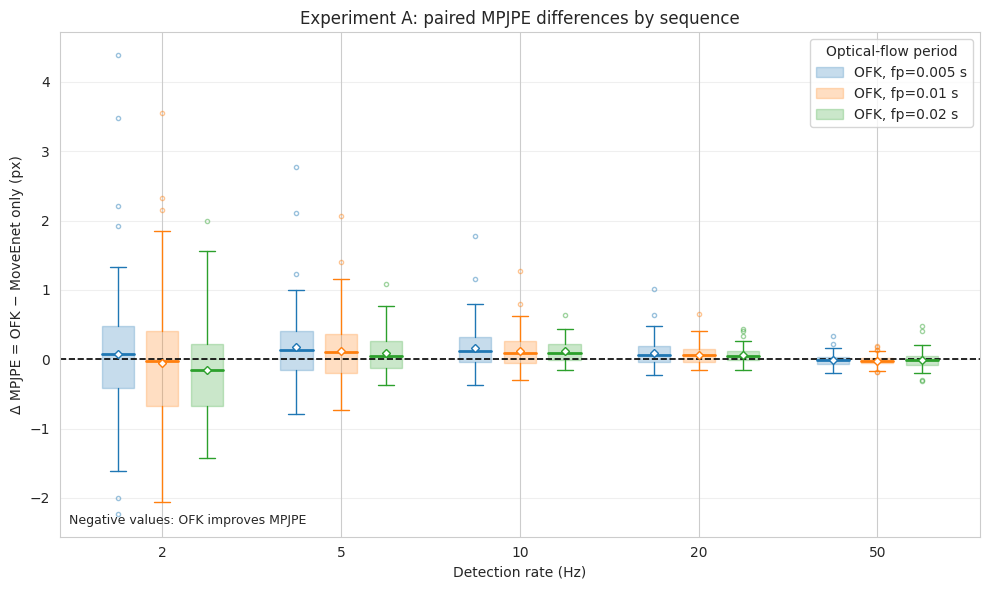

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/mpjpe_paired_difference_boxplot.png


In [124]:
# -----------------------------------------------------------------------------
# Boxplot of paired MPJPE differences
# -----------------------------------------------------------------------------

from matplotlib.patches import Patch

detection_rates = sorted(
    df_paired['detection_rate_hz'].dropna().unique()
)

flow_periods = sorted(
    df_paired['flow_period_s'].dropna().unique()
)

rate_positions = np.arange(len(detection_rates))

n_flow_periods = len(flow_periods)

group_width = 0.75
position_step = group_width / max(n_flow_periods, 1)
box_width = position_step * 0.72

offsets = (
    np.arange(n_flow_periods)
    - (n_flow_periods - 1) / 2.0
) * position_step

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(figsize=(10, 6))

legend_handles = []

for flow_index, flow_period_s in enumerate(flow_periods):
    color = colors[flow_index % len(colors)]

    boxplot_values = []
    boxplot_positions = []

    for rate_index, detection_rate_hz in enumerate(detection_rates):
        selected = df_paired[
            np.isclose(
                df_paired['flow_period_s'],
                flow_period_s,
            ) &
            np.isclose(
                df_paired['detection_rate_hz'],
                detection_rate_hz,
            )
        ]

        values = selected['delta_mpjpe_px'].dropna().to_numpy()

        if len(values) == 0:
            continue

        boxplot_values.append(values)

        boxplot_positions.append(
            rate_positions[rate_index]
            + offsets[flow_index]
        )

    if len(boxplot_values) == 0:
        continue

    boxplot_result = ax.boxplot(
        boxplot_values,
        positions=boxplot_positions,
        widths=box_width,
        patch_artist=True,
        showmeans=True,
        showfliers=True,
        manage_ticks=False,
        medianprops={
            'color': color,
            'linewidth': 2,
        },
        meanprops={
            'marker': 'D',
            'markerfacecolor': 'white',
            'markeredgecolor': color,
            'markersize': 4,
        },
        whiskerprops={
            'color': color,
        },
        capprops={
            'color': color,
        },
        flierprops={
            'marker': '.',
            'markeredgecolor': color,
            'alpha': 0.45,
        },
    )

    for box in boxplot_result['boxes']:
        box.set_facecolor(color)
        box.set_edgecolor(color)
        box.set_alpha(0.25)

    legend_handles.append(
        Patch(
            facecolor=color,
            edgecolor=color,
            alpha=0.25,
            label=f'OFK, fp={flow_period_s:g} s',
        )
    )


# Zero means identical MPJPE.
ax.axhline(
    0.0,
    color='black',
    linestyle='--',
    linewidth=1.2,
)

ax.set_xticks(rate_positions)
ax.set_xticklabels(
    [f'{rate:g}' for rate in detection_rates]
)

ax.set_xlabel('Detection rate (Hz)')
ax.set_ylabel(
    'Δ MPJPE = OFK − MoveEnet only (px)'
)

ax.set_title(
    'Experiment A: paired MPJPE differences by sequence'
)

ax.grid(
    True,
    axis='y',
    alpha=0.3,
)

ax.legend(
    handles=legend_handles,
    title='Optical-flow period',
)

# Add an explanation directly under the x-axis.
ax.text(
    0.01,
    0.02,
    'Negative values: OFK improves MPJPE',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
)

plt.tight_layout()

boxplot_path = (
    PLOTS_DIR /
    'mpjpe_paired_difference_boxplot.png'
)

plt.savefig(
    boxplot_path,
    dpi=180,
    bbox_inches='tight',
)

plt.show()

print('Saved:', boxplot_path)

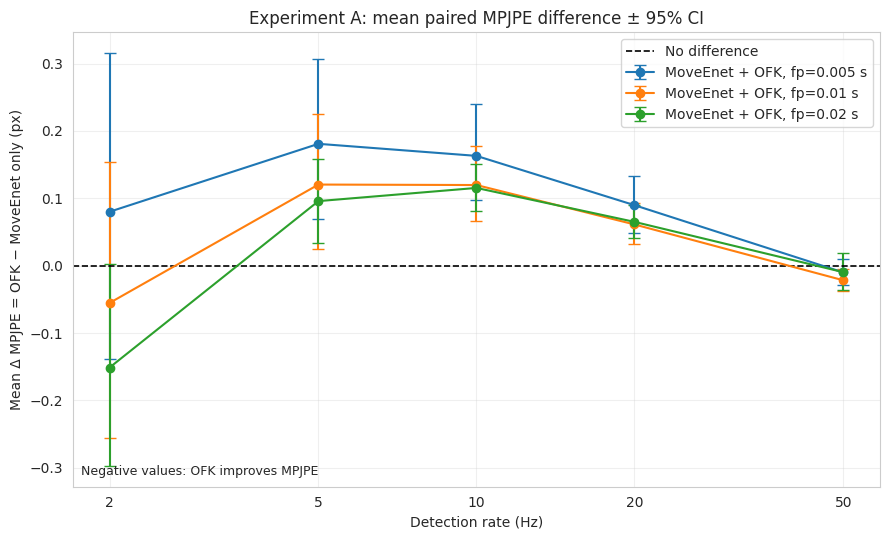

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/mpjpe_mean_paired_difference_95ci.png


In [125]:
# -----------------------------------------------------------------------------
# Mean paired MPJPE difference with 95% bootstrap confidence interval
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5.5))

for flow_period_s in sorted(
    df_delta_summary['flow_period_s'].dropna().unique()
):
    selected = df_delta_summary[
        np.isclose(
            df_delta_summary['flow_period_s'],
            flow_period_s,
        )
    ].sort_values('detection_rate_hz')

    if len(selected) == 0:
        continue

    mean_difference = selected[
        'mean_delta_mpjpe_px'
    ].to_numpy()

    ci_low = selected[
        'ci95_low_px'
    ].to_numpy()

    ci_high = selected[
        'ci95_high_px'
    ].to_numpy()

    # Matplotlib expects distances from the mean, not absolute bounds.
    lower_error = mean_difference - ci_low
    upper_error = ci_high - mean_difference

    asymmetric_error = np.vstack([
        lower_error,
        upper_error,
    ])

    ax.errorbar(
        selected['detection_rate_hz'],
        mean_difference,
        yerr=asymmetric_error,
        marker='o',
        capsize=4,
        linewidth=1.5,
        label=f'MoveEnet + OFK, fp={flow_period_s:g} s',
    )


# Reference: no difference between OFK and MoveEnet-only.
ax.axhline(
    0.0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='No difference',
)

ax.set_xscale('log')

set_actual_x_ticks(
    ax,
    df_delta_summary['detection_rate_hz'],
)

ax.set_xlabel('Detection rate (Hz)')
ax.set_ylabel(
    'Mean Δ MPJPE = OFK − MoveEnet only (px)'
)

ax.set_title(
    'Experiment A: mean paired MPJPE difference ± 95% CI'
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

ax.text(
    0.01,
    0.02,
    'Negative values: OFK improves MPJPE',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
)

plt.tight_layout()

difference_plot_path = (
    PLOTS_DIR /
    'mpjpe_mean_paired_difference_95ci.png'
)

plt.savefig(
    difference_plot_path,
    dpi=180,
    bbox_inches='tight',
)

plt.show()

print('Saved:', difference_plot_path)

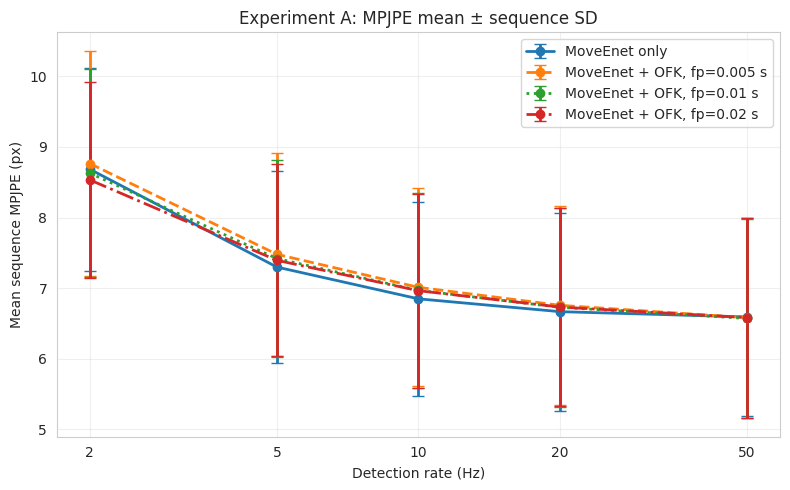

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/mpjpe_sequence_mean_std_vs_detection_rate.png


In [126]:
plot_path = PLOTS_DIR / 'mpjpe_sequence_mean_std_vs_detection_rate.png'

plot_metric_by_method_and_flow(
    table=df_mpjpe_sequence_stats,
    x_col='detection_rate_hz',
    y_col='mpjpe_px',
    yerr_col='mpjpe_std_px',
    ylabel='Mean sequence MPJPE (px)',
    title='Experiment A: MPJPE mean ± sequence SD',
    output_path=plot_path,
    xscale='log',
)

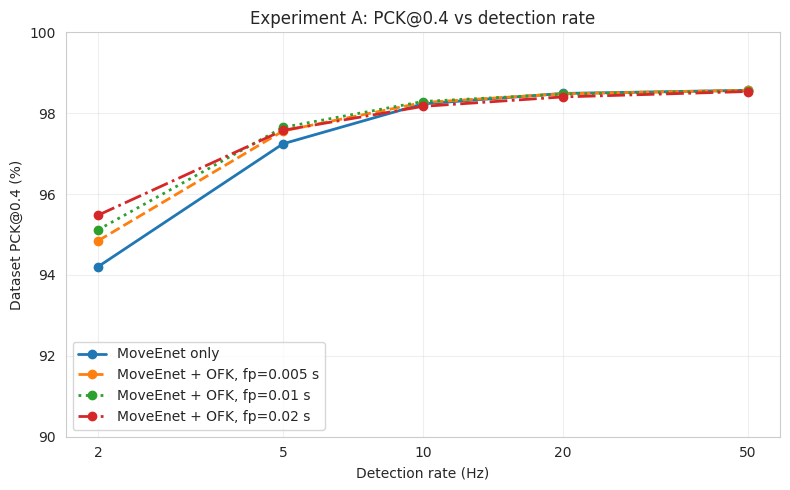

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/pck_0.4_vs_detection_rate.png


In [138]:
PRIMARY_PCK_THRESHOLD = 0.4
pck_col = f'pck_{PRIMARY_PCK_THRESHOLD:.1f}'

if pck_col not in df_table.columns:
    raise RuntimeError(f'Missing PCK column: {pck_col}')

plot_path = PLOTS_DIR / f'pck_{PRIMARY_PCK_THRESHOLD:.1f}_vs_detection_rate.png'

plot_metric_by_method_and_flow(
    table=df_table,
    x_col='detection_rate_hz',
    y_col=pck_col,
    ylabel=f'Dataset PCK@{PRIMARY_PCK_THRESHOLD:.1f} (%)',
    title=(
        f'Experiment A: PCK@{PRIMARY_PCK_THRESHOLD:.1f} '
        'vs detection rate'
    ),
    output_path=plot_path,
    xscale='log',
    ylim=(90, 100),
)


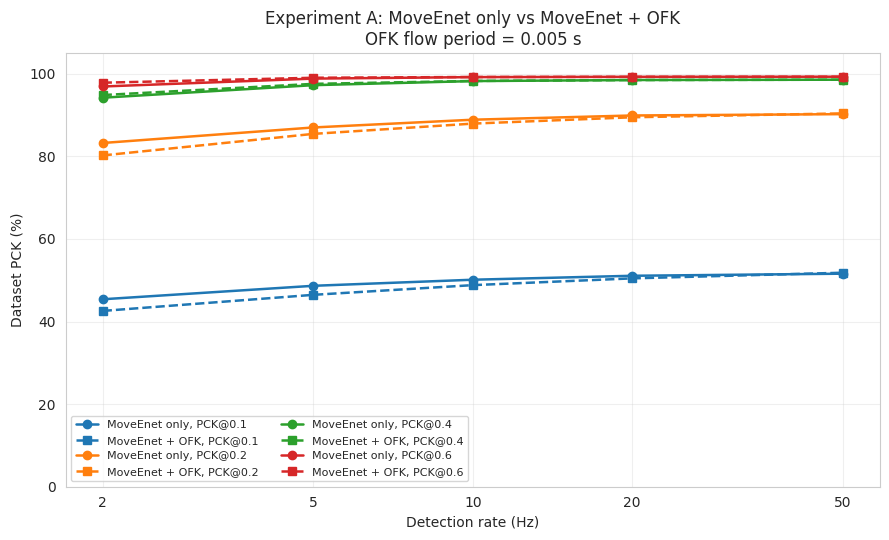

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/pck_movenet_only_vs_ofk_fp_0p005.png


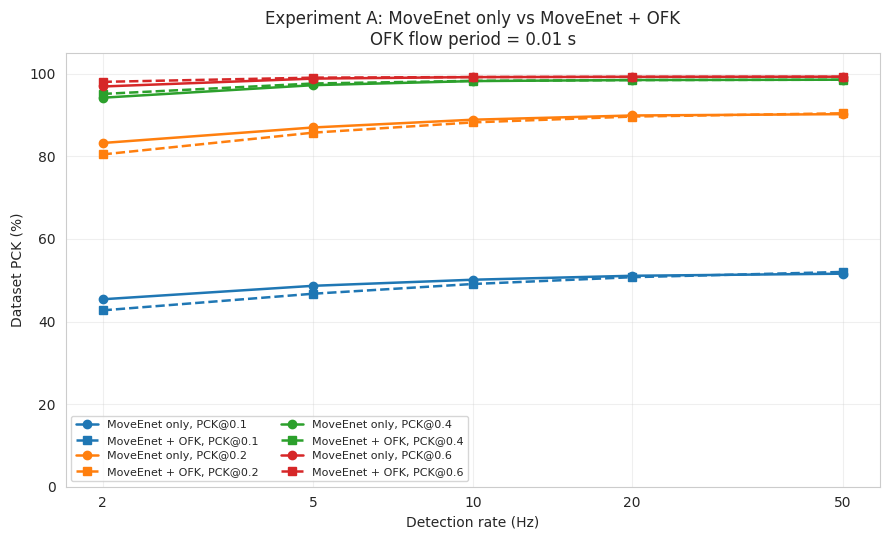

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/pck_movenet_only_vs_ofk_fp_0p01.png


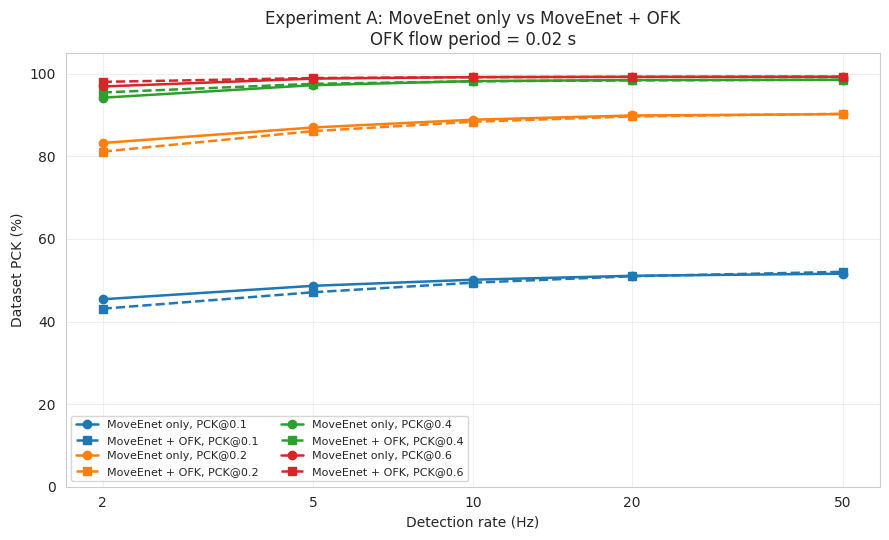

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/pck_movenet_only_vs_ofk_fp_0p02.png


In [128]:
# -----------------------------------------------------------------------------
# PCK comparison:
# one separate figure for each OFK flow period.
#
# Each figure compares:
#   - MoveEnet only
#   - MoveEnet + OFK with one specific flow period
# -----------------------------------------------------------------------------

ofk_flow_periods = [0.005, 0.01, 0.02]

# MoveEnet-only baseline.
# MoveEnet only does not actually depend on the optical-flow period.
# In df_table it is stored only for the canonical flow period.
d_movenet_only = df_table[
    (df_table['method'] == 'MoveEnet only') &
    np.isclose(
        df_table['flow_period_s'],
        MOVENET_ONLY_FLOW_PERIOD
    )
].sort_values('detection_rate_hz')


if len(d_movenet_only) == 0:
    raise RuntimeError(
        'No MoveEnet-only results were found in df_table.'
    )


# Use the same color for the same PCK threshold in all figures.
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

threshold_colors = {
    threshold: default_colors[index % len(default_colors)]
    for index, threshold in enumerate(pck_thresholds)
}


for flow_period_s in ofk_flow_periods:

    # Select only the OFK configuration associated with this flow period.
    d_ofk = df_table[
        (df_table['method'] == 'MoveEnet + OFK') &
        np.isclose(
            df_table['flow_period_s'],
            flow_period_s
        )
    ].sort_values('detection_rate_hz')


    if len(d_ofk) == 0:
        print(
            f'[WARNING] No MoveEnet + OFK data found for '
            f'flow period {flow_period_s:g} s'
        )
        continue


    fig, ax = plt.subplots(figsize=(9, 5.5))


    for threshold in pck_thresholds:
        pck_col = f'pck_{threshold:.1f}'

        if pck_col not in df_table.columns:
            print(f'[WARNING] Missing column: {pck_col}')
            continue

        color = threshold_colors[threshold]


        # MoveEnet-only curve.
        ax.plot(
            d_movenet_only['detection_rate_hz'],
            d_movenet_only[pck_col],
            marker='o',
            linestyle='-',
            linewidth=1.8,
            color=color,
            label=f'MoveEnet only, PCK@{threshold:.1f}',
        )


        # MoveEnet + OFK curve.
        ax.plot(
            d_ofk['detection_rate_hz'],
            d_ofk[pck_col],
            marker='s',
            linestyle='--',
            linewidth=1.8,
            color=color,
            label=(
                f'MoveEnet + OFK, PCK@{threshold:.1f}'
            ),
        )


    ax.set_xscale('log')

    set_actual_x_ticks(
        ax,
        df_table['detection_rate_hz']
    )

    ax.set_xlabel('Detection rate (Hz)')
    ax.set_ylabel('Dataset PCK (%)')

    ax.set_title(
        'Experiment A: MoveEnet only vs MoveEnet + OFK\n'
        f'OFK flow period = {flow_period_s:g} s'
    )

    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3)

    ax.legend(
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()


    # Convert, for example, 0.005 -> 0p005 for the filename.
    flow_period_tag = (
        f'{flow_period_s:g}'.replace('.', 'p')
    )

    plot_path = (
        PLOTS_DIR /
        f'pck_movenet_only_vs_ofk_fp_{flow_period_tag}.png'
    )

    plt.savefig(
        plot_path,
        dpi=180,
        bbox_inches='tight',
    )

    plt.show()

    print('Saved:', plot_path)


,flow_period_s,network_period_s,detection_rate_hz,method,n_sequences,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.005,0.02,50.0,MoveEnet + OFK,79,277751,6.630619,51.826609,90.409423,98.567837,99.295135
1,0.005,0.02,50.0,MoveEnet only,79,277751,6.644225,51.591229,90.226331,98.566120,99.291230
2,0.005,0.05,20.0,MoveEnet + OFK,79,277751,6.790448,50.455070,89.467572,98.480931,99.268742
3,0.005,0.05,20.0,MoveEnet only,79,277751,6.711935,51.084217,89.901359,98.489211,99.262843
4,0.005,0.10,10.0,MoveEnet + OFK,79,277751,7.028076,48.817494,87.934406,98.263996,99.220026
5,0.005,0.10,10.0,MoveEnet only,79,277751,6.881212,50.126995,88.877891,98.230707,99.194159
6,0.005,0.20,5.0,MoveEnet + OFK,79,277751,7.466665,46.470760,85.448144,97.560377,99.038070
7,0.005,0.20,5.0,MoveEnet only,79,277751,7.304019,48.657140,87.000698,97.243436,98.830220
8,0.005,0.50,2.0,MoveEnet + OFK,79,277751,8.678712,42.572498,80.226174,94.845992,97.837410
9,0.005,0.50,2.0,MoveEnet only,79,277751,8.628659,45.394339,83.239858,94.205463,96.921066


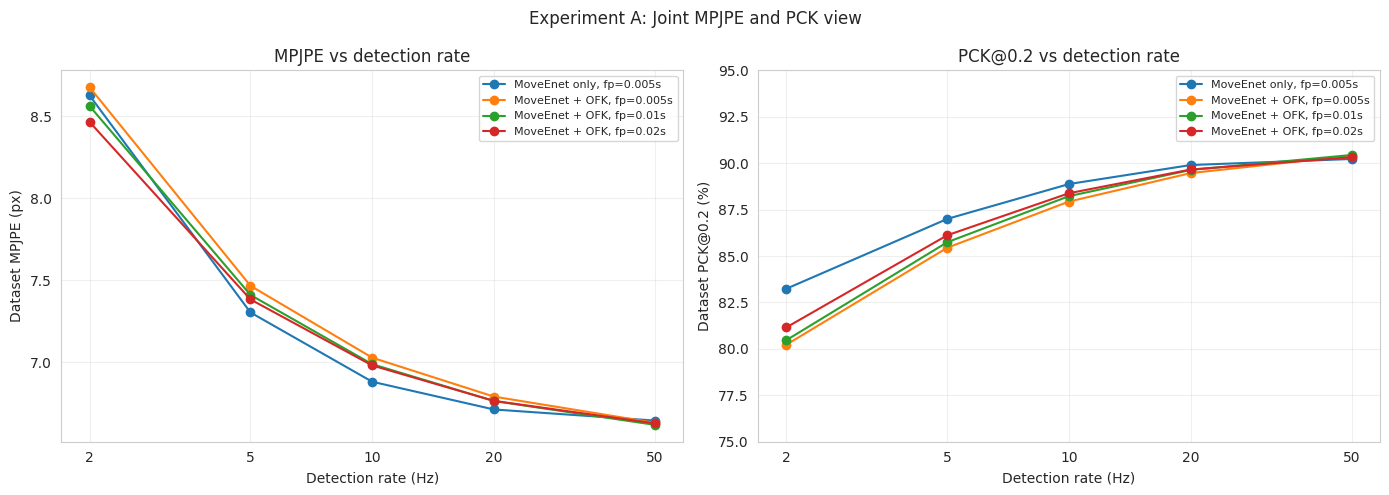

Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/combined_mpjpe_pck_0.2_vs_detection_rate_dataset_weighted.png


In [136]:
primary_pck_threshold = 0.2
primary_col = f'pck_{primary_pck_threshold:.1f}'

compact_cols = [
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
    'method',
    'n_sequences',
    'n_samples',
    'mpjpe_px',
] + [f'pck_{th:.1f}' for th in pck_thresholds if f'pck_{th:.1f}' in df_table.columns]

compact_combined = df_table[compact_cols].copy()
display(compact_combined)

# -------------------------------------------------------------------------
# Side-by-side MPJPE and PCK plot against detection rate.
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for flow_period_s in sorted(df_table['flow_period_s'].dropna().unique()):
    for method in ['MoveEnet only', 'MoveEnet + OFK']:
        d = df_table[
            (df_table['flow_period_s'] == flow_period_s) &
            (df_table['method'] == method)
        ].sort_values('detection_rate_hz')

        if len(d) == 0:
            continue

        label = f'{method}, fp={flow_period_s:g}s'

        axes[0].plot(d['detection_rate_hz'], d['mpjpe_px'], marker='o', label=label)

        if primary_col in d.columns:
            axes[1].plot(d['detection_rate_hz'], d[primary_col], marker='o', label=label)

for ax in axes:
    ax.set_xscale('log')
    set_actual_x_ticks(ax, df_table['detection_rate_hz'])
    ax.set_xlabel('Detection rate (Hz)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Dataset MPJPE (px)')
axes[0].set_title('MPJPE vs detection rate')

axes[1].set_ylabel(f'Dataset PCK@{primary_pck_threshold:.1f} (%)')
axes[1].set_title(f'PCK@{primary_pck_threshold:.1f} vs detection rate')
axes[1].set_ylim([75, 95])

plt.suptitle('Experiment A: Joint MPJPE and PCK view')
plt.tight_layout()

plot_path = PLOTS_DIR / f'combined_mpjpe_pck_{primary_pck_threshold:.1f}_vs_detection_rate_dataset_weighted.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


In [130]:
# Dataset-level per-joint MPJPE.
# Each joint is weighted by the number of samples contributing to that sequence row.

per_joint_cols = [f'mpjpe_{joint}' for joint in joint_names]
sum_joint_cols = [f'sum_err_{joint}' for joint in joint_names]

missing_sum_cols = [c for c in sum_joint_cols if c not in df_seq.columns]
if missing_sum_cols:
    raise RuntimeError(f'Missing per-joint sum columns: {missing_sum_cols[:5]}')

joint_agg_dict = {
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for col in sum_joint_cols:
    joint_agg_dict[col] = (col, 'sum')

agg_mpjpe_joints = (
    df_seq
    .groupby(group_cols, as_index=False)
    .agg(**joint_agg_dict)
)

for joint in joint_names:
    agg_mpjpe_joints[f'mpjpe_{joint}'] = (
        agg_mpjpe_joints[f'sum_err_{joint}'] / agg_mpjpe_joints['n_samples']
    )

agg_mpjpe_joints = (
    agg_mpjpe_joints[
        group_cols + ['n_sequences', 'n_samples'] + per_joint_cols
    ]
    .sort_values(['flow_period_s', 'network_period_s', 'method'])
    .reset_index(drop=True)
)

# display(agg_mpjpe_joints)

per_joint_path = SUMMARY_DIR / 'mpjpe_per_joint_dataset_weighted.csv'
agg_mpjpe_joints.to_csv(per_joint_path, index=False)
print('Saved:', per_joint_path)


Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/mpjpe_per_joint_dataset_weighted.csv


In [131]:
# Dataset-level per-joint PCK.
# Each per-joint PCK is weighted by the number of evaluated samples.

work_joint_pck = df_seq.copy()

pck_joint_cols = []
for th in pck_thresholds:
    for joint in joint_names:
        col = f'pck_{th:.1f}_{joint}'
        if col in work_joint_pck.columns:
            pck_joint_cols.append(col)
            work_joint_pck[f'{col}_correct_samples'] = (
                work_joint_pck[col] / 100.0
            ) * work_joint_pck['n_samples']

joint_pck_agg_dict = {
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for col in pck_joint_cols:
    joint_pck_agg_dict[f'{col}_correct_samples'] = (f'{col}_correct_samples', 'sum')

agg_pck_joints = (
    work_joint_pck
    .groupby(group_cols, as_index=False)
    .agg(**joint_pck_agg_dict)
)

for col in pck_joint_cols:
    agg_pck_joints[col] = (
        agg_pck_joints[f'{col}_correct_samples'] / agg_pck_joints['n_samples'] * 100.0
    )

drop_cols = [f'{col}_correct_samples' for col in pck_joint_cols]
agg_pck_joints = agg_pck_joints.drop(columns=drop_cols)

agg_pck_joints = (
    agg_pck_joints
    .sort_values(['flow_period_s', 'network_period_s', 'method'])
    .reset_index(drop=True)
)

# display(agg_pck_joints)

per_joint_pck_path = SUMMARY_DIR / 'pck_per_joint_dataset_weighted.csv'
agg_pck_joints.to_csv(per_joint_pck_path, index=False)
print('Saved:', per_joint_pck_path)


Saved: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/summary/pck_per_joint_dataset_weighted.csv


/tmp/ipykernel_67406/2881972263.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_pck_joints[col] = (
/tmp/ipykernel_67406/2881972263.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_pck_joints[col] = (
/tmp/ipykernel_67406/2881972263.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [132]:
print('=' * 100)
print('EXPERIMENT A - COMBINED MPJPE AND PCK SUMMARY')
print('Aggregation: dataset-level weighted by evaluated joint/sample count')
print('=' * 100)

for flow_period_s in sorted(df_table['flow_period_s'].dropna().unique()):
    print(f'\nFlow period: {flow_period_s:g} s')
    print('-' * 100)

    for method in ['MoveEnet only', 'MoveEnet + OFK']:
        d_method = df_table[
            (df_table['flow_period_s'] == flow_period_s) &
            (df_table['method'] == method)
        ].sort_values('network_period_s')

        if len(d_method) == 0:
            continue

        print(f'\n{method}')

        for _, row in d_method.iterrows():
            period_s = float(row['network_period_s'])
            rate_hz = float(row['detection_rate_hz'])
            n_sequences = int(row['n_sequences'])
            n_samples = int(row['n_samples'])
            n_points = int(row['n_points'])

            print(f'  Network period: {period_s:g} s | Detection rate: {rate_hz:g} Hz')
            print(f"    MPJPE: {row['mpjpe_px']:.3f} px")
            print(f'    Sequences: {n_sequences} | Samples: {n_samples} | Joint points: {n_points}')

            for th in pck_thresholds:
                col = f'pck_{th:.1f}'
                if col in row:
                    print(f"    PCK@{th:.1f}: {row[col]:.2f}%")

print('\nSaved outputs:')
print('  Summary CSVs ->', SUMMARY_DIR)
print('  Plots        ->', PLOTS_DIR)
print('=' * 100)


EXPERIMENT A - COMBINED MPJPE AND PCK SUMMARY
Aggregation: dataset-level weighted by evaluated joint/sample count

Flow period: 0.005 s
----------------------------------------------------------------------------------------------------

MoveEnet only
  Network period: 0.02 s | Detection rate: 50 Hz
    MPJPE: 6.644 px
    Sequences: 79 | Samples: 277751 | Joint points: 3610763
    PCK@0.1: 51.59%
    PCK@0.2: 90.23%
    PCK@0.4: 98.57%
    PCK@0.6: 99.29%
  Network period: 0.05 s | Detection rate: 20 Hz
    MPJPE: 6.712 px
    Sequences: 79 | Samples: 277751 | Joint points: 3610763
    PCK@0.1: 51.08%
    PCK@0.2: 89.90%
    PCK@0.4: 98.49%
    PCK@0.6: 99.26%
  Network period: 0.1 s | Detection rate: 10 Hz
    MPJPE: 6.881 px
    Sequences: 79 | Samples: 277751 | Joint points: 3610763
    PCK@0.1: 50.13%
    PCK@0.2: 88.88%
    PCK@0.4: 98.23%
    PCK@0.6: 99.19%
  Network period: 0.2 s | Detection rate: 5 Hz
    MPJPE: 7.304 px
    Sequences: 79 | Samples: 277751 | Joint points: 361

SELECTED_SEQUENCE was None, using: S13_1_1__ch2dvs
OFK CSV: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw/fp_0p02/np_0p05/S13_1_1__ch2dvs_moveenet_ofk_np_0p05_fp_0p02.csv
MoveEnet-only CSV: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw/fp_0p005/np_0p05/S13_1_1__ch2dvs_moveenet_only_np_0p05_fp_0p005.csv
OFK CSV: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw/fp_0p02/np_0p05/S13_1_1__ch2dvs_moveenet_ofk_np_0p05_fp_0p02.csv
MoveEnet-only CSV: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/results/raw/fp_0p005/np_0p05/S13_1_1__ch2dvs_moveenet_only_np_0p05_fp_0p005.csv


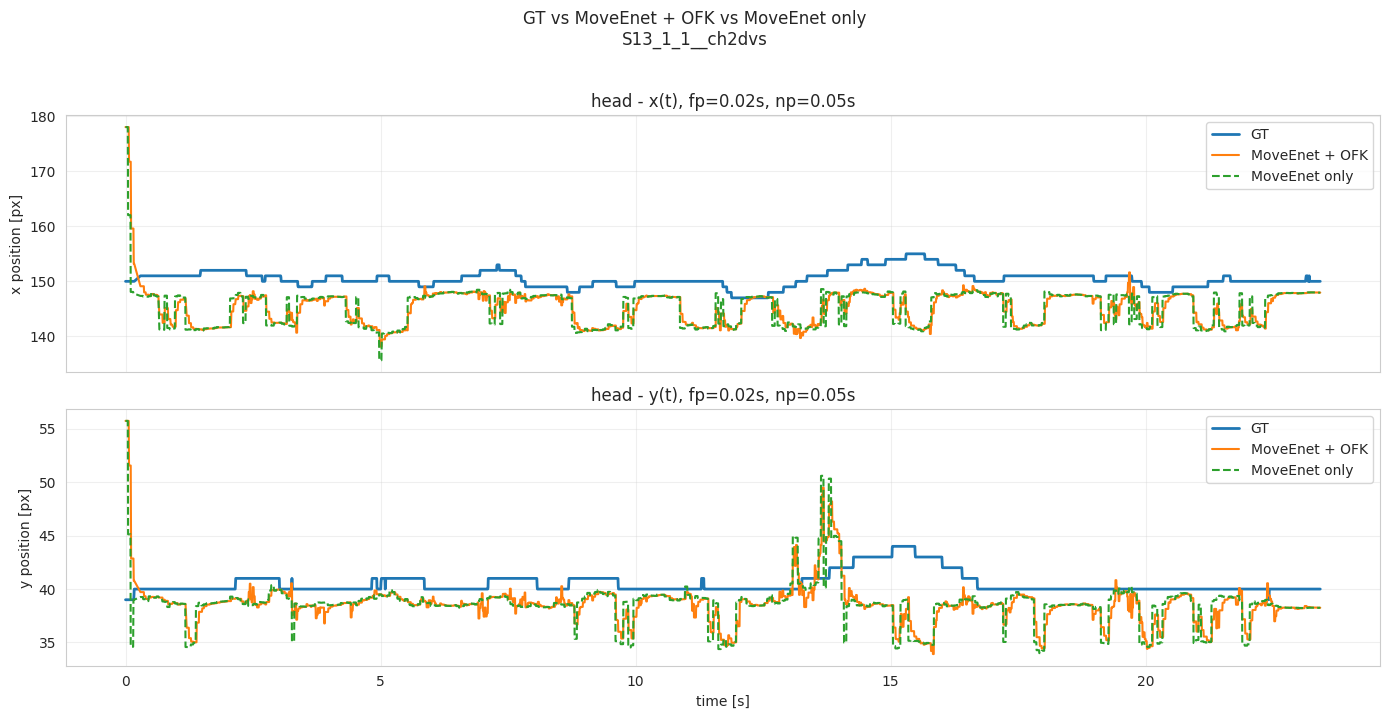

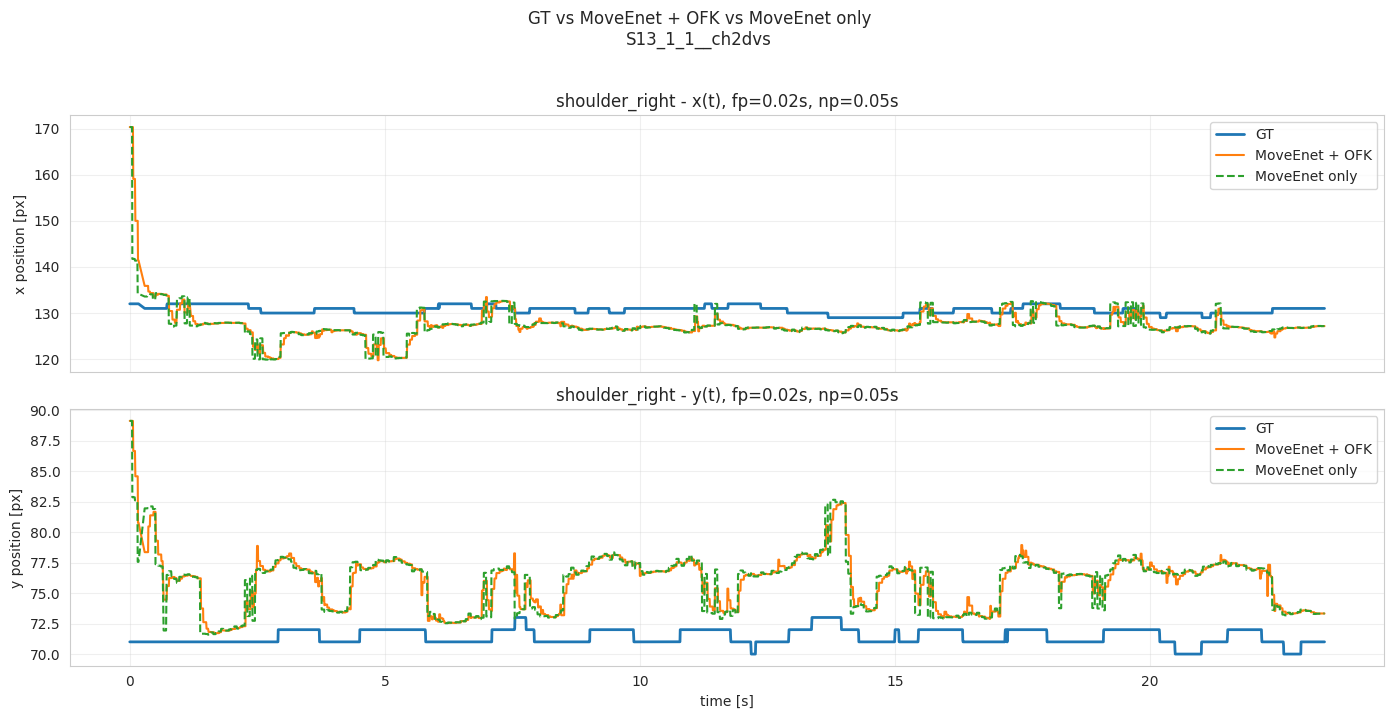

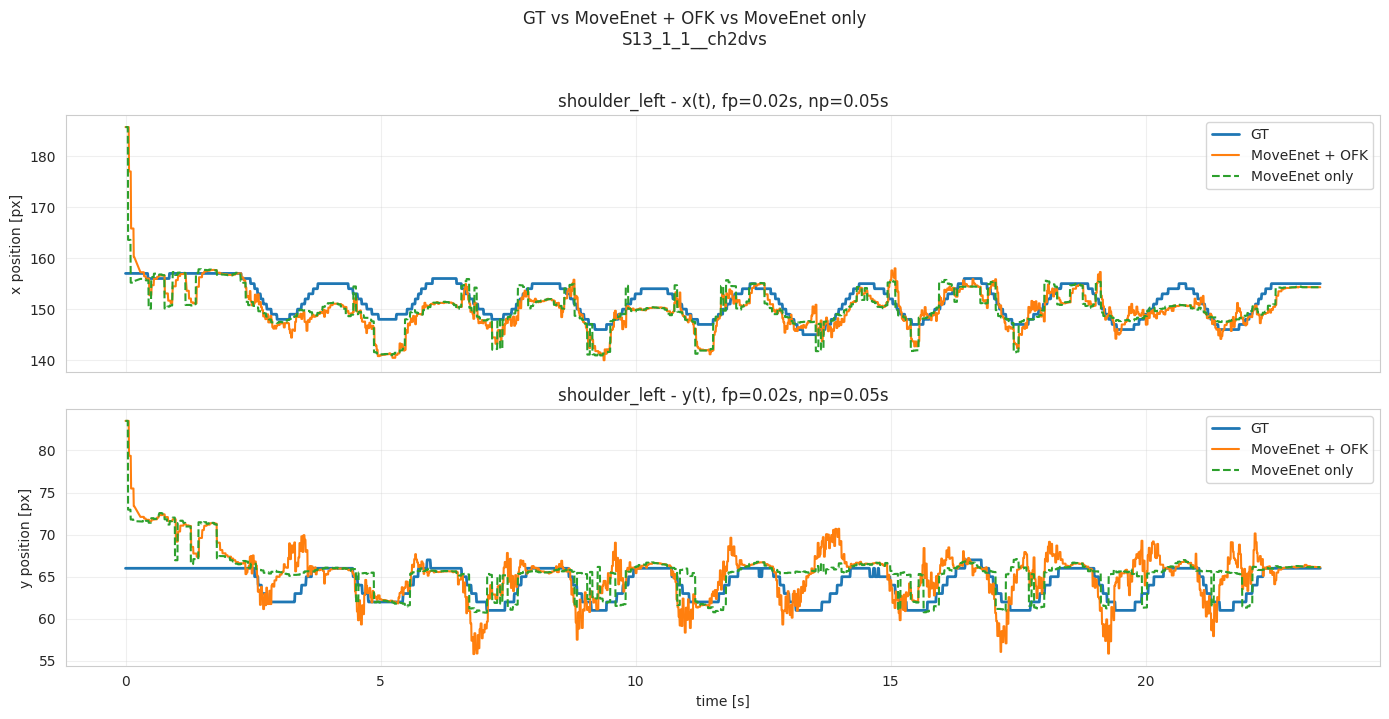

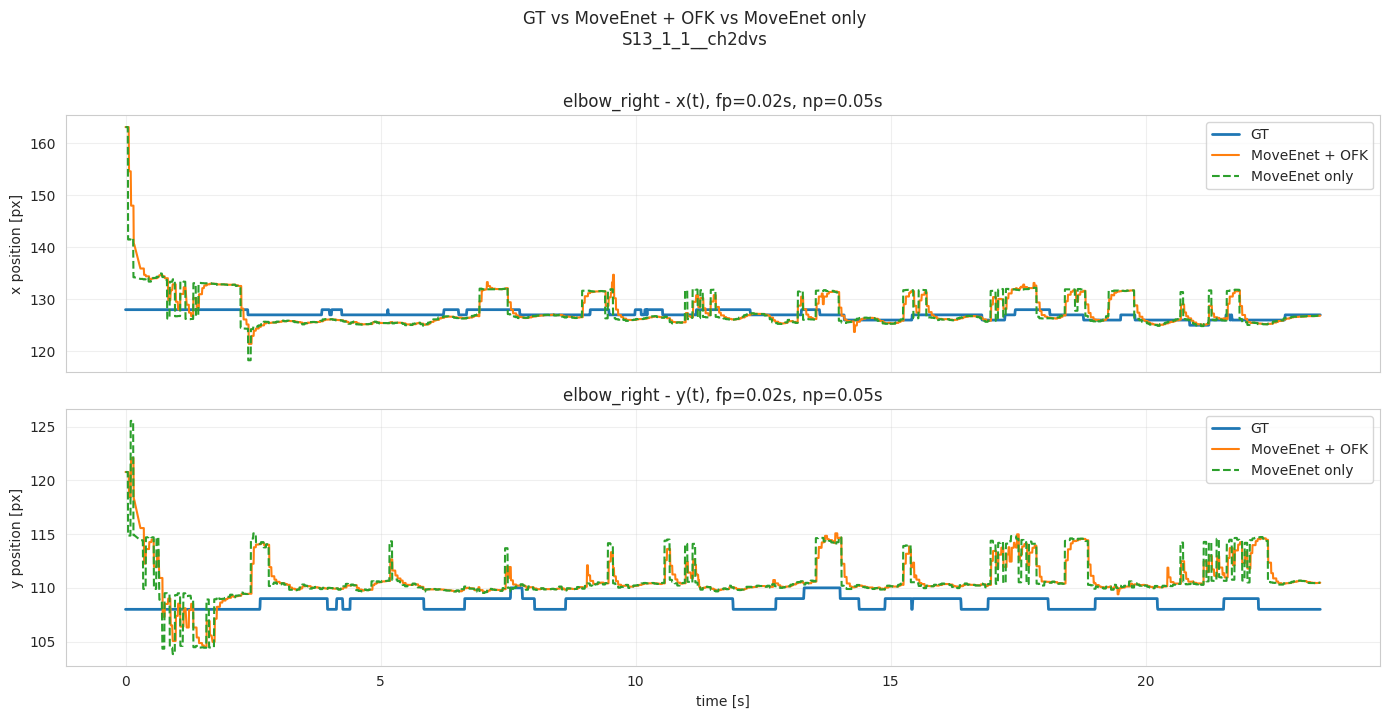

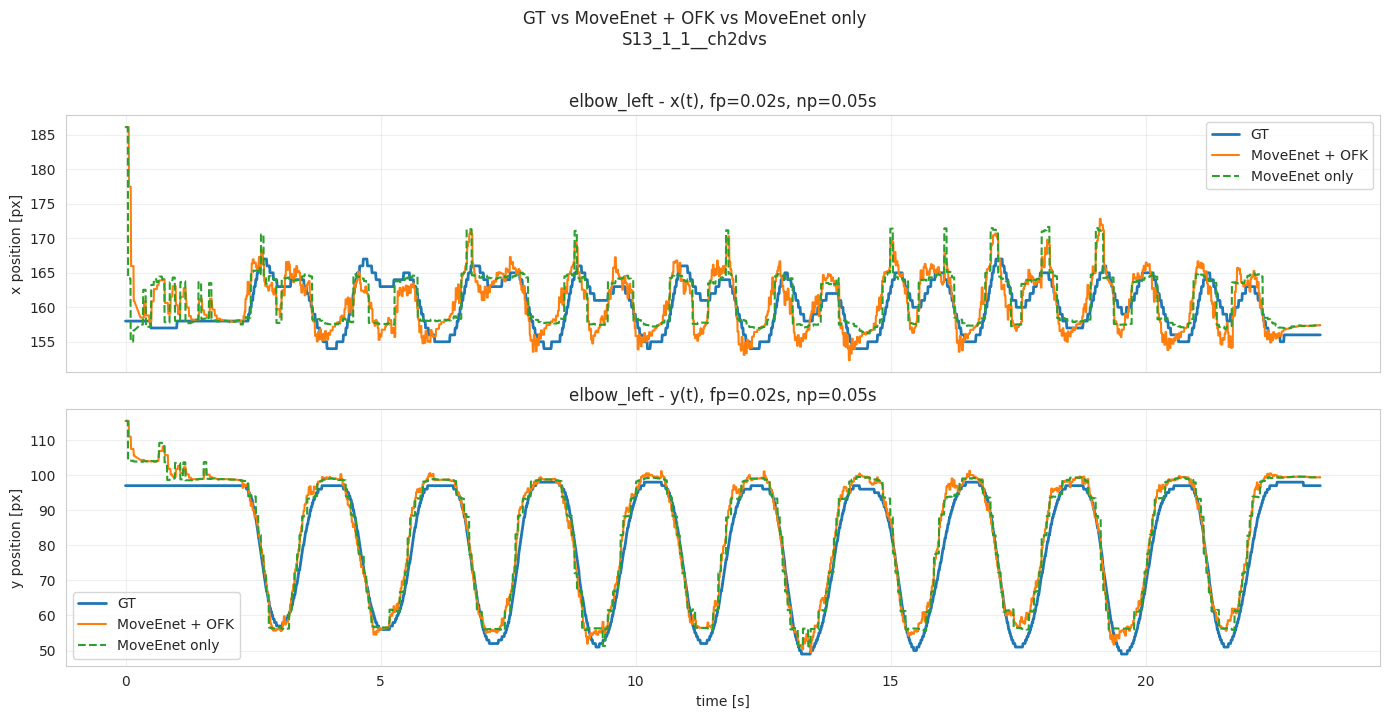

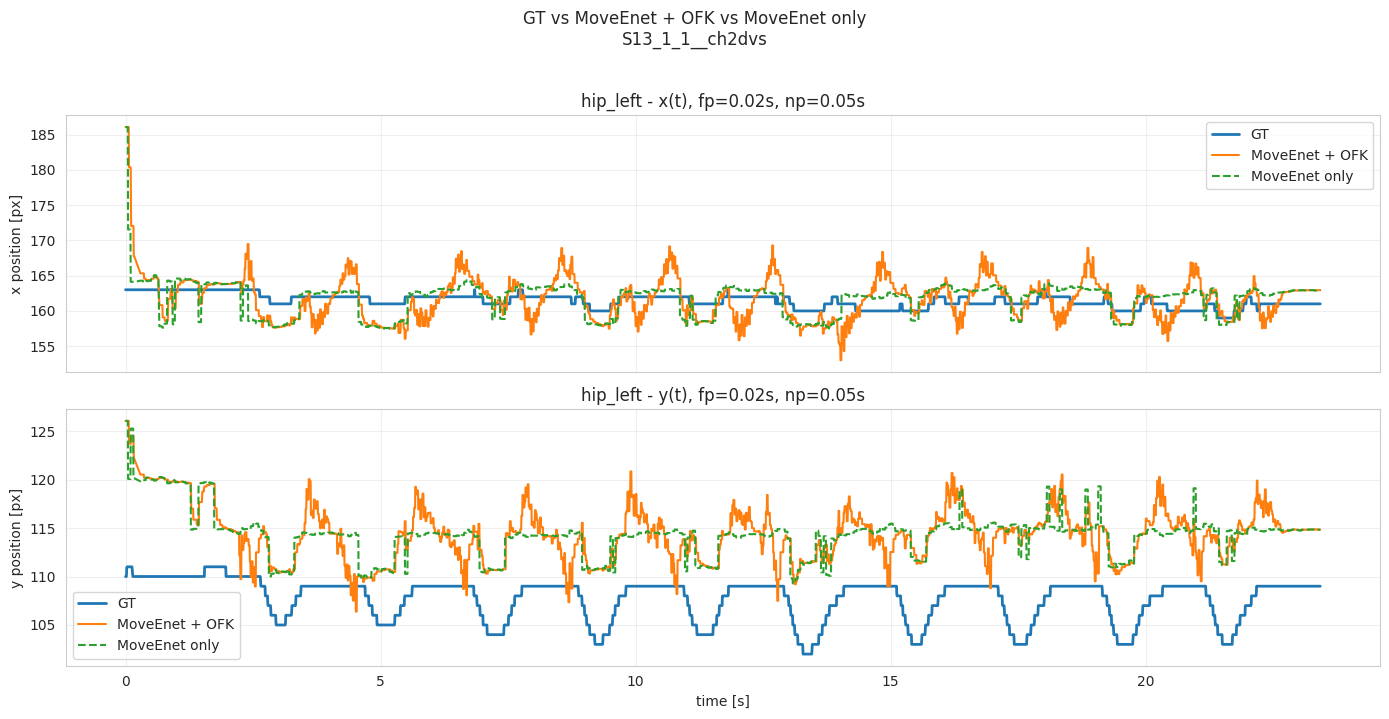

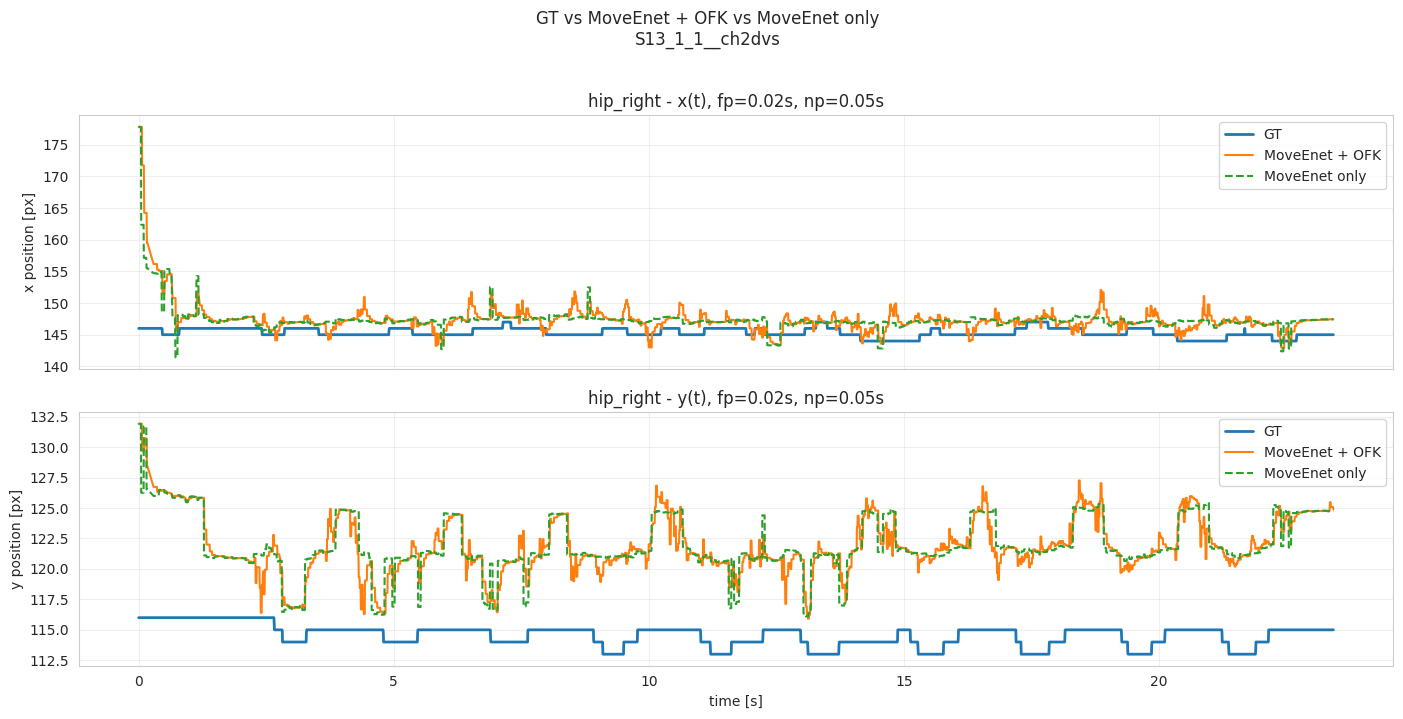

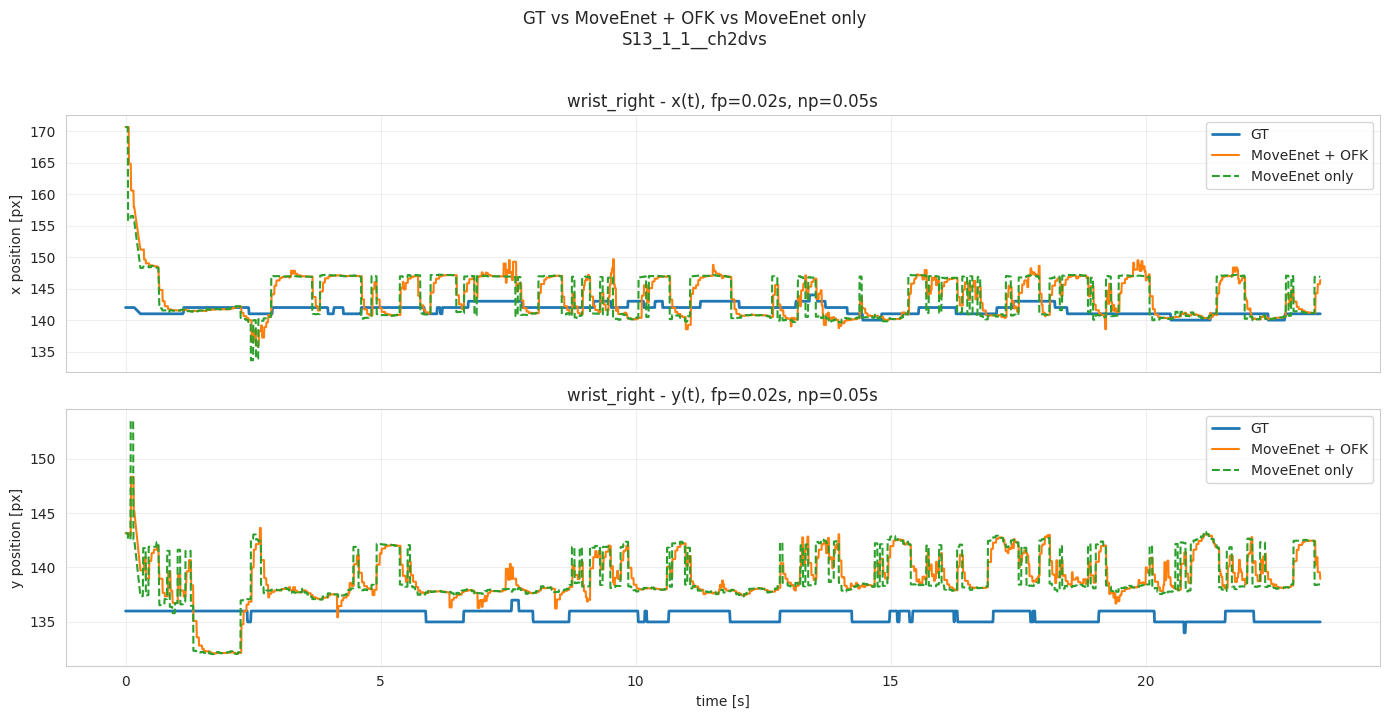

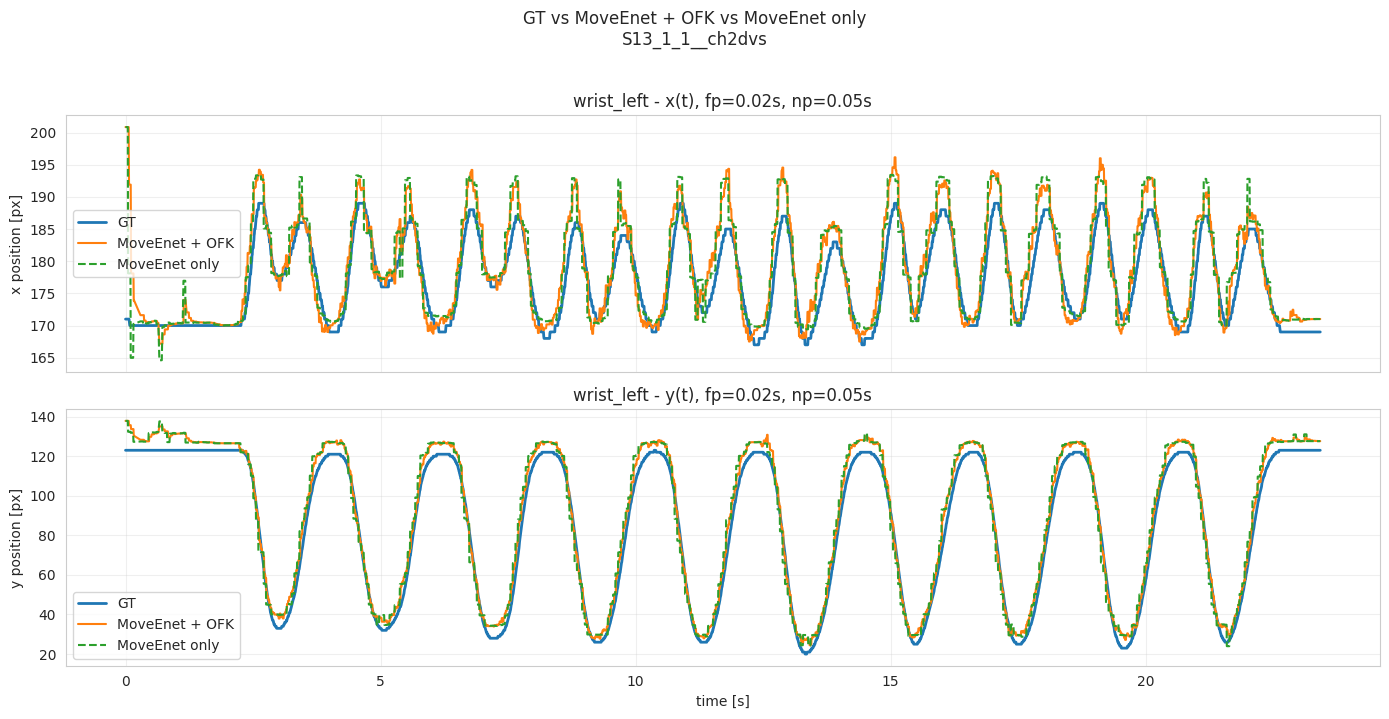

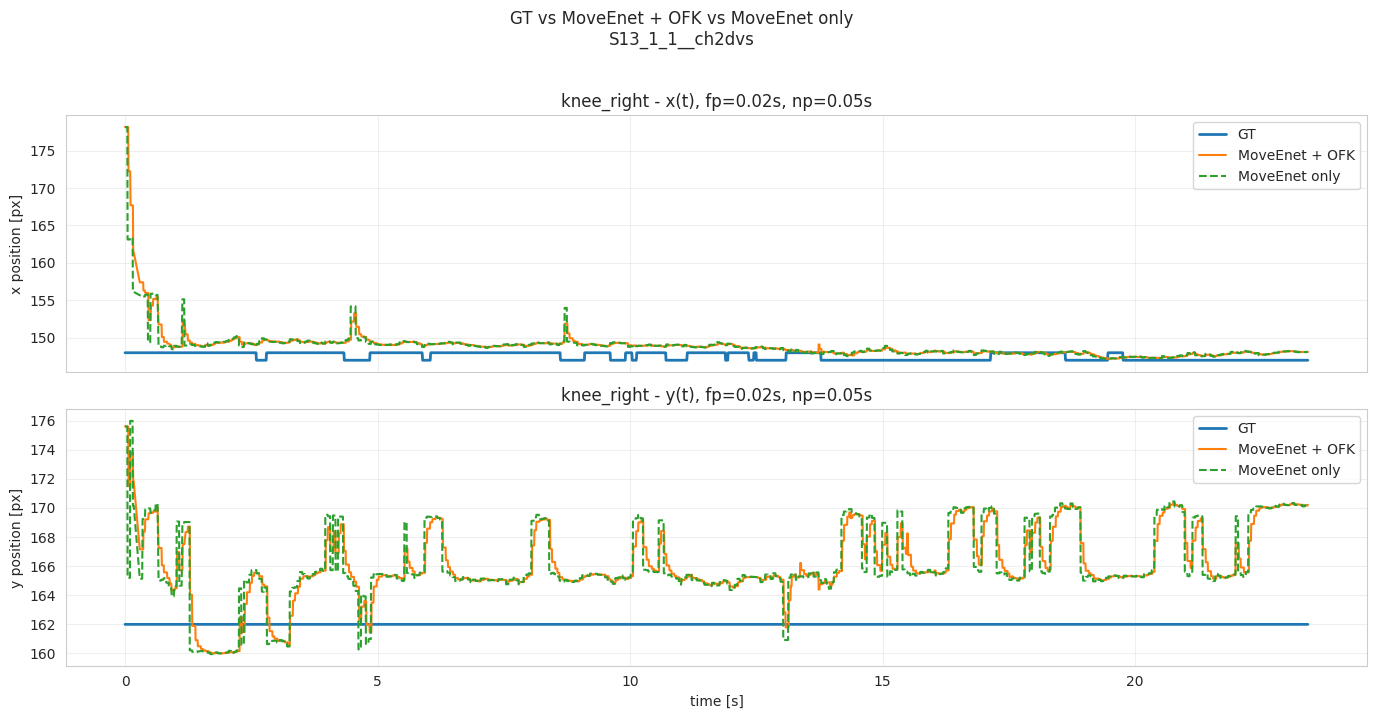

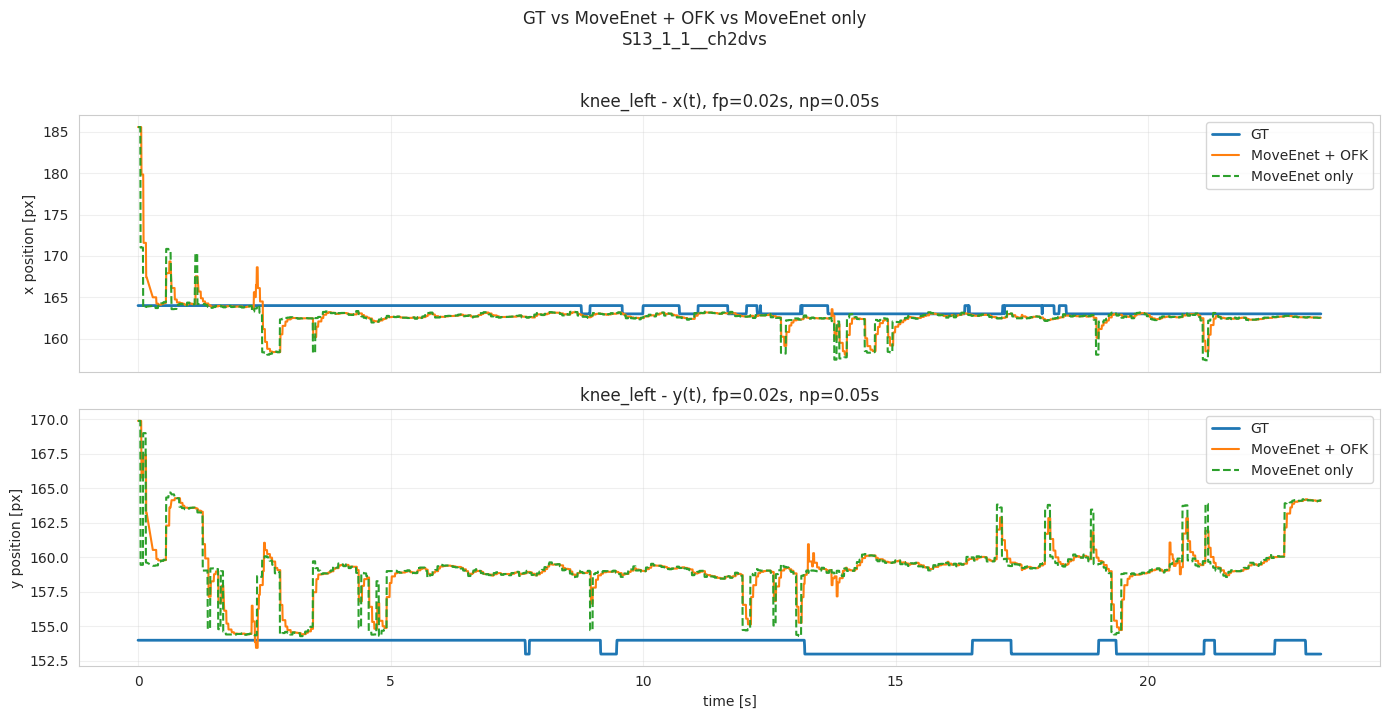

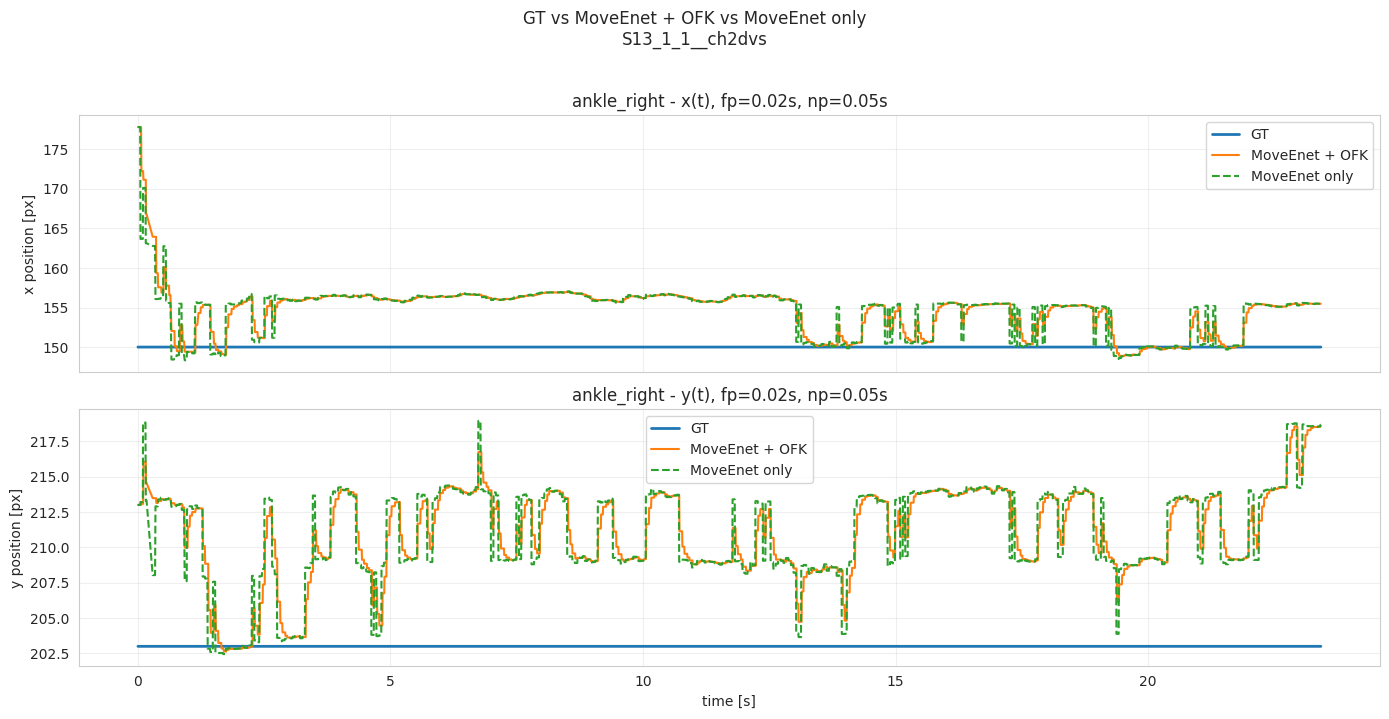

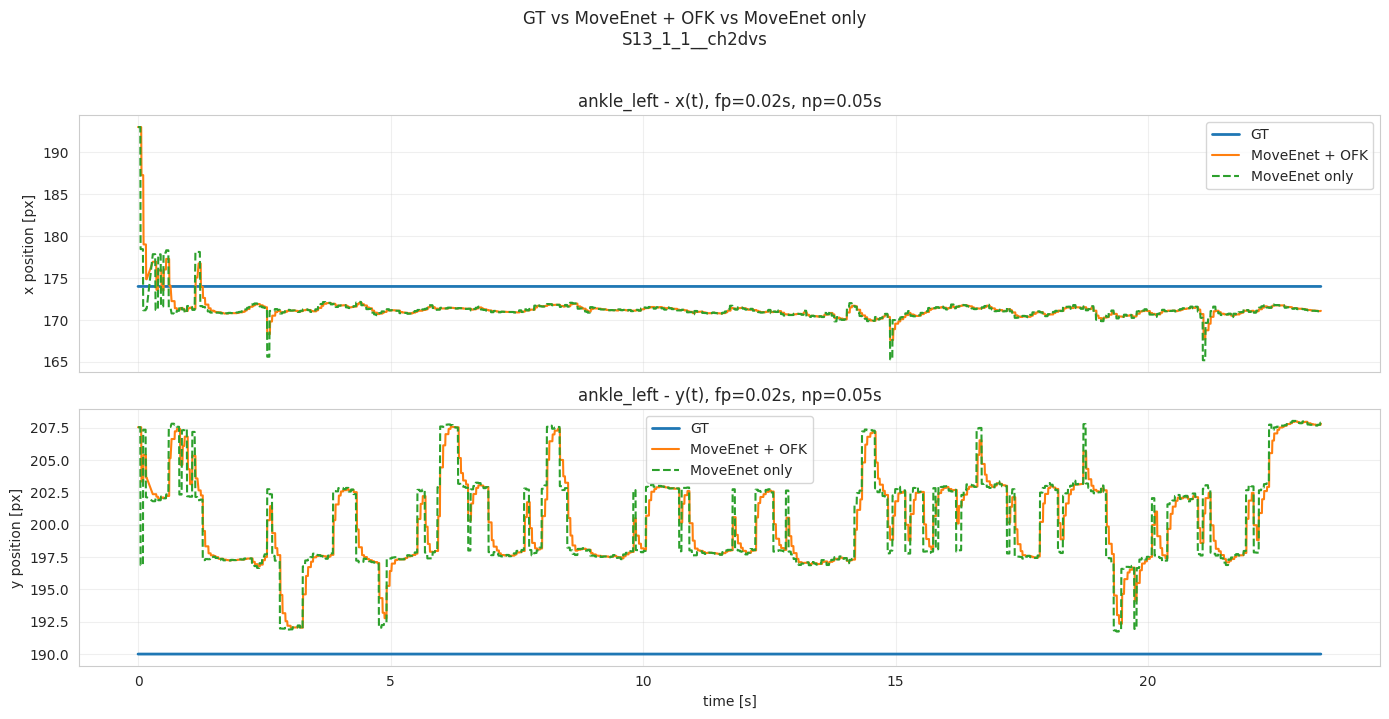

Saved PDF: /workspace/moveEnetFlow/experiments/ExpA/expA_accuracy_vs_network_period/dhp19_full_test/plots/timed_joint_comparison/S13_1_1__ch2dvs_gt_vs_ofk_vs_movenetonly_fp_0p02_np_0p05.pdf


In [133]:
# -----------------------------------------------------------------------------
# Time plots: GT vs MoveEnet + OFK vs MoveEnet only, for all joints
# -----------------------------------------------------------------------------
# This cell creates time-series plots for one selected sequence/configuration.
# For each joint, it plots x(t) and y(t) comparing:
#   - GT
#   - MoveEnet + OFK
#   - MoveEnet only
#
# Required from previous notebook cells:
#   df_seq
#   load_pred_eval_csv
#   gt_path_from_seq_key
#   interp_gt_to_pred_ts
#   ds_parsing
#   joint_names
#   DATASET
#   PLOTS_DIR
# -----------------------------------------------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------------------------------------------------------
# Select what you want to inspect
# -----------------------------------------------------------------------------

SELECTED_SEQUENCE = None
# Example:
# SELECTED_SEQUENCE = "S13_1_1__ch2dvs"
# SELECTED_SEQUENCE = "cam2_S11_Directions__ch0dvs"

SELECTED_FLOW_PERIOD = 0.02
SELECTED_NETWORK_PERIOD = 0.05

# Optional time crop in seconds.
# Set to None to plot the whole sequence.
TIME_START = None
TIME_END = None

# -------------------------------------------------------------------------
# Select the MoveEnet + OFK experiment
# -------------------------------------------------------------------------
# OFK depends on the selected flow period.

ofk_available = df_seq[
    (df_seq["method"] == "MoveEnet + OFK") &
    np.isclose(
        df_seq["flow_period_s"],
        SELECTED_FLOW_PERIOD
    ) &
    np.isclose(
        df_seq["network_period_s"],
        SELECTED_NETWORK_PERIOD
    )
].copy()

if len(ofk_available) == 0:
    raise RuntimeError(
        f"No MoveEnet + OFK rows found for "
        f"flow_period={SELECTED_FLOW_PERIOD} and "
        f"network_period={SELECTED_NETWORK_PERIOD}"
    )


# -------------------------------------------------------------------------
# Select the sequence
# -------------------------------------------------------------------------

if SELECTED_SEQUENCE is None:
    SELECTED_SEQUENCE = sorted(
        ofk_available["sequence"].unique()
    )[0]

    print(
        "SELECTED_SEQUENCE was None, using:",
        SELECTED_SEQUENCE
    )


# -------------------------------------------------------------------------
# Get the selected MoveEnet + OFK row
# -------------------------------------------------------------------------

ofk_rows = ofk_available[
    ofk_available["sequence"] == SELECTED_SEQUENCE
].copy()

if len(ofk_rows) != 1:
    raise RuntimeError(
        f"Expected one MoveEnet + OFK row for "
        f"sequence={SELECTED_SEQUENCE}, "
        f"fp={SELECTED_FLOW_PERIOD}, "
        f"np={SELECTED_NETWORK_PERIOD}; "
        f"found {len(ofk_rows)}"
    )


# -------------------------------------------------------------------------
# Get the corresponding MoveEnet-only row
# -------------------------------------------------------------------------
# MoveEnet-only is stored only under the canonical flow-period folder.
# Its network period and sequence must match the OFK experiment.

mn_rows = df_seq[
    (df_seq["method"] == "MoveEnet only") &
    (df_seq["sequence"] == SELECTED_SEQUENCE) &
    np.isclose(
        df_seq["flow_period_s"],
        MOVENET_ONLY_FLOW_PERIOD
    ) &
    np.isclose(
        df_seq["network_period_s"],
        SELECTED_NETWORK_PERIOD
    )
].copy()

if len(mn_rows) != 1:
    raise RuntimeError(
        f"Expected one MoveEnet-only row for "
        f"sequence={SELECTED_SEQUENCE}, "
        f"canonical fp={MOVENET_ONLY_FLOW_PERIOD}, "
        f"np={SELECTED_NETWORK_PERIOD}; "
        f"found {len(mn_rows)}"
    )


# -------------------------------------------------------------------------
# Prediction CSV paths
# -------------------------------------------------------------------------

csv_ofk = Path(ofk_rows.iloc[0]["csv_path"])
csv_mn = Path(mn_rows.iloc[0]["csv_path"])

print("OFK CSV:", csv_ofk)
print("MoveEnet-only CSV:", csv_mn)

if len(ofk_rows) != 1:
    raise RuntimeError(f"Expected one MoveEnet + OFK row, found {len(ofk_rows)}")

if len(mn_rows) != 1:
    raise RuntimeError(f"Expected one MoveEnet only row, found {len(mn_rows)}")

csv_ofk = Path(ofk_rows.iloc[0]["csv_path"])
csv_mn = Path(mn_rows.iloc[0]["csv_path"])

print("OFK CSV:", csv_ofk)
print("MoveEnet-only CSV:", csv_mn)

# -----------------------------------------------------------------------------
# Load predictions
# -----------------------------------------------------------------------------

ts_ofk, joints_ofk = load_pred_eval_csv(csv_ofk)
ts_mn, joints_mn = load_pred_eval_csv(csv_mn)

# -----------------------------------------------------------------------------
# Load GT and interpolate GT to each prediction timeline
# -----------------------------------------------------------------------------

gt_path = gt_path_from_seq_key(SELECTED_SEQUENCE, dataset=DATASET)

if not gt_path.exists():
    raise FileNotFoundError(f"GT file not found: {gt_path}")

gt_data = ds_parsing.import_yarp_skeleton_data(
    gt_path,
    multi_channel=False
)

joints_gt_ofk_ts = interp_gt_to_pred_ts(gt_data, ts_ofk)
joints_gt_mn_ts = interp_gt_to_pred_ts(gt_data, ts_mn)

# -----------------------------------------------------------------------------
# Optional time crop
# -----------------------------------------------------------------------------

def crop_by_time(ts, joints, t_start=None, t_end=None):
    mask = np.ones_like(ts, dtype=bool)

    if t_start is not None:
        mask &= ts >= t_start

    if t_end is not None:
        mask &= ts <= t_end

    return ts[mask], joints[mask]

ts_ofk_plot, joints_ofk_plot = crop_by_time(
    ts_ofk,
    joints_ofk,
    TIME_START,
    TIME_END
)

_, joints_gt_ofk_plot = crop_by_time(
    ts_ofk,
    joints_gt_ofk_ts,
    TIME_START,
    TIME_END
)

ts_mn_plot, joints_mn_plot = crop_by_time(
    ts_mn,
    joints_mn,
    TIME_START,
    TIME_END
)

_, joints_gt_mn_plot = crop_by_time(
    ts_mn,
    joints_gt_mn_ts,
    TIME_START,
    TIME_END
)

if len(ts_ofk_plot) == 0 or len(ts_mn_plot) == 0:
    raise RuntimeError("Time crop produced empty arrays. Check TIME_START and TIME_END.")

# For plotting GT, use the OFK time base as reference.
# OFK and MoveEnet-only are plotted on their own timestamps.
ts0 = min(ts_ofk_plot[0], ts_mn_plot[0])
t_ofk = ts_ofk_plot - ts0
t_mn = ts_mn_plot - ts0

# -----------------------------------------------------------------------------
# Output paths
# -----------------------------------------------------------------------------

timed_plot_dir = PLOTS_DIR / "timed_joint_comparison"
timed_plot_dir.mkdir(parents=True, exist_ok=True)

safe_seq = SELECTED_SEQUENCE.replace("/", "__").replace(" ", "_")
safe_fp = str(SELECTED_FLOW_PERIOD).replace(".", "p")
safe_np = str(SELECTED_NETWORK_PERIOD).replace(".", "p")

pdf_path = (
    timed_plot_dir /
    f"{safe_seq}_gt_vs_ofk_vs_movenetonly_fp_{safe_fp}_np_{safe_np}.pdf"
)

# -----------------------------------------------------------------------------
# One PDF page per joint: x(t) and y(t)
# -----------------------------------------------------------------------------

with PdfPages(pdf_path) as pdf:
    for j, joint_name in enumerate(joint_names):
        fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

        # x coordinate
        axes[0].plot(
            t_ofk,
            joints_gt_ofk_plot[:, j, 0],
            linewidth=2,
            label="GT"
        )
        axes[0].plot(
            t_ofk,
            joints_ofk_plot[:, j, 0],
            linewidth=1.5,
            label="MoveEnet + OFK"
        )
        axes[0].plot(
            t_mn,
            joints_mn_plot[:, j, 0],
            linewidth=1.5,
            linestyle="--",
            label="MoveEnet only"
        )
        axes[0].set_ylabel("x position [px]")
        axes[0].set_title(
            f"{joint_name} - x(t), "
            f"fp={SELECTED_FLOW_PERIOD:g}s, "
            f"np={SELECTED_NETWORK_PERIOD:g}s"
        )
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # y coordinate
        axes[1].plot(
            t_ofk,
            joints_gt_ofk_plot[:, j, 1],
            linewidth=2,
            label="GT"
        )
        axes[1].plot(
            t_ofk,
            joints_ofk_plot[:, j, 1],
            linewidth=1.5,
            label="MoveEnet + OFK"
        )
        axes[1].plot(
            t_mn,
            joints_mn_plot[:, j, 1],
            linewidth=1.5,
            linestyle="--",
            label="MoveEnet only"
        )
        axes[1].set_ylabel("y position [px]")
        axes[1].set_xlabel("time [s]")
        axes[1].set_title(
            f"{joint_name} - y(t), "
            f"fp={SELECTED_FLOW_PERIOD:g}s, "
            f"np={SELECTED_NETWORK_PERIOD:g}s"
        )
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        fig.suptitle(
            f"GT vs MoveEnet + OFK vs MoveEnet only\n"
            f"{SELECTED_SEQUENCE}",
            y=1.02
        )

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print("Saved PDF:", pdf_path)